# 01 — Análisis Exploratorio de Datos (EDA)

**TFM — Valoración Inmobiliaria Masiva: SLX vs Machine Learning**  
Dataset: King County House Prices (21.613 viviendas, 2014–2015)

---

## ¿Para qué sirve este notebook?

Antes de entrenar cualquier modelo necesitamos entender los datos crudos:
- **¿Qué forma tiene la distribución del precio?** → Decide si transformamos la variable objetivo
- **¿Hay outliers o errores?** → Decide qué limpiar en el notebook 02
- **¿Qué variables se correlacionan más con el precio?** → Orienta qué features serán más importantes
- **¿Existe estructura espacial en el precio?** → Justifica por qué añadimos KNN lags en el notebook 03
- **¿Qué peculiaridades tienen variables como `yr_renovated`?** → Decide cómo tratarlas en preprocessing

Los outputs (figuras) se guardan en `outputs/figures/` para usarlos en la memoria del TFM.

---

### Contenido
1. Setup y carga
2. Visión general: shape, dtypes, primeras filas
3. Estadísticos descriptivos
4. Variable objetivo `price`: distribución y transformación logarítmica
5. Correlaciones con el precio
6. Variables de superficie (`sqft_*`)
7. Variables de calidad y condición (`grade`, `condition`, `view`, `waterfront`)
8. Variables temporales (`yr_built`, `yr_renovated`, `date`)
9. Variables categóricas (`floors`, `bedrooms`, `bathrooms`)
10. Dimensión espacial: qué son los archivos shapefile y para qué sirven
11. Variación de precio por zipcode
12. Mapas geográficos del gradiente de precio
13. Autocorrelación espacial: diagrama de Moran
14. Detección de outliers
15. Resumen y decisiones para preprocessing

---
## 1. Setup y carga de datos

Importamos las librerías necesarias y establecemos la configuración global de gráficos.
- `pandas` / `numpy`: manipulación de datos
- `matplotlib` / `seaborn`: visualizaciones estáticas
- `geopandas`: lectura y visualización de datos geoespaciales (shapefiles)
- `scipy.stats`: tests estadísticos (ANOVA, t-test, QQ-plot)
- `sklearn.neighbors.BallTree`: cálculo eficiente de vecinos más cercanos para el lag espacial manual

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import geopandas as gpd
from scipy import stats
from scipy.stats import norm
from sklearn.neighbors import BallTree
import warnings
import os

warnings.filterwarnings('ignore')

# Rutas
RAW_PATH    = '../data/raw/kc_house_data.csv'
SPATIAL_ZIP = '../data/spatial/King_county_zip.shp'
SPATIAL_PTS = '../data/spatial/kc_house.shp'
FIG_PATH    = '../outputs/figures/'
os.makedirs(FIG_PATH, exist_ok=True)

# Estilo global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
SEED = 42

# Carga
df = pd.read_csv(RAW_PATH)
print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

Dataset cargado: 21,613 filas × 21 columnas


---
## 2. Visión general: shape, tipos y primeras filas

Comprobamos que todas las columnas están bien leídas y no hay nulos. También revisamos los tipos de datos para identificar variables que necesiten conversión:
- `date` viene como string → hay que parsearla
- `yr_renovated` usa 0 para indicar «no renovada» → no es un año real
- `zipcode` es numérico pero es una categoría

In [2]:
print('=== Primeras filas ===')
display(df.head())

=== Primeras filas ===


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
print('=== Tipos de dato, nulos y cardinalidad ===')
info = pd.DataFrame({
    'dtype'   : df.dtypes,
    'nulos'   : df.isnull().sum(),
    '% nulos' : (df.isnull().mean() * 100).round(2),
    'únicos'  : df.nunique(),
    'ejemplo' : df.iloc[0]
})
display(info)
print(f'\nTotal nulos: {df.isnull().sum().sum()} ✓')

=== Tipos de dato, nulos y cardinalidad ===


,dtype,nulos,% nulos,únicos,ejemplo
id,int64,0,0.0,21436,7129300520
date,object,0,0.0,372,20141013T000000
price,float64,0,0.0,4028,221900.0
bedrooms,int64,0,0.0,13,3
bathrooms,float64,0,0.0,30,1.0
sqft_living,int64,0,0.0,1038,1180
sqft_lot,int64,0,0.0,9782,5650
floors,float64,0,0.0,6,1.0
waterfront,int64,0,0.0,2,0
view,int64,0,0.0,5,0



Total nulos: 0 ✓


---
## 3. Estadísticos descriptivos

Un `describe()` ampliado con coeficiente de variación y skewness nos da la escala de cada variable, su dispersión y sus extremos.

Puntos de atención:
- **`price`**: media muy superior a la mediana → distribución sesgada a la derecha (skewness > 4)
- **`bedrooms` max = 33** → outlier claro, probablemente error de entrada
- **`sqft_lot` max = 1.65M ft²** → hay terrenos enormes que pueden distorsionar
- **`yr_renovated` min = 0** → código especial, no es un año real
- **`sqft_basement`**: muchos ceros (viviendas sin sótano)

In [4]:
desc = df.describe().T
desc['cv']   = (desc['std'] / desc['mean'] * 100).round(1)   # Coeficiente de variación
desc['skew'] = df.select_dtypes('number').skew().round(3)
display(
    desc.style
    .background_gradient(subset=['cv', 'skew'], cmap='RdYlGn_r')
    .format(precision=2)
)

,count,mean,std,min,25%,50%,75%,max,cv,skew
id,21613.00,4580301520.86,2876565571.31,1000102.00,2123049194.00,3904930410.00,7308900445.00,9900000190.00,62.80,0.24
price,21613.00,540088.14,367127.20,75000.00,321950.00,450000.00,645000.00,7700000.00,68.00,4.02
bedrooms,21613.00,3.37,0.93,0.00,3.00,3.00,4.00,33.00,27.60,1.97
bathrooms,21613.00,2.11,0.77,0.00,1.75,2.25,2.50,8.00,36.40,0.51
sqft_living,21613.00,2079.90,918.44,290.00,1427.00,1910.00,2550.00,13540.00,44.20,1.47
sqft_lot,21613.00,15106.97,41420.51,520.00,5040.00,7618.00,10688.00,1651359.00,274.20,13.06
floors,21613.00,1.49,0.54,1.00,1.00,1.50,2.00,3.50,36.10,0.62
waterfront,21613.00,0.01,0.09,0.00,0.00,0.00,0.00,1.00,1147.20,11.38
view,21613.00,0.23,0.77,0.00,0.00,0.00,0.00,4.00,327.10,3.40
condition,21613.00,3.41,0.65,1.00,3.00,3.00,4.00,5.00,19.10,1.03


---
## 4. Variable objetivo `price`: distribución y transformación logarítmica

### ¿Por qué aplicar log?

Los modelos de regresión y árboles con métrica MSE funcionan mejor cuando la variable objetivo tiene una distribución aproximadamente simétrica. El precio de vivienda suele seguir una **distribución log-normal**: la mayoría son viviendas de precio medio, pero hay pocas muy caras que crean una cola larga a la derecha.

Al aplicar `log(price)`:
- Reducimos el skewness de ~4 a ~0.4, aproximando la normal
- Convertimos el error en **error porcentual** (más interpretable en inmobiliaria)
- Evitamos que las viviendas de lujo dominen el entrenamiento
- Mejora la homocedasticidad de los residuos

Los Q-Q plots comparan la distribución empírica contra una normal teórica: cuanto más siguen la línea recta, más normales son.

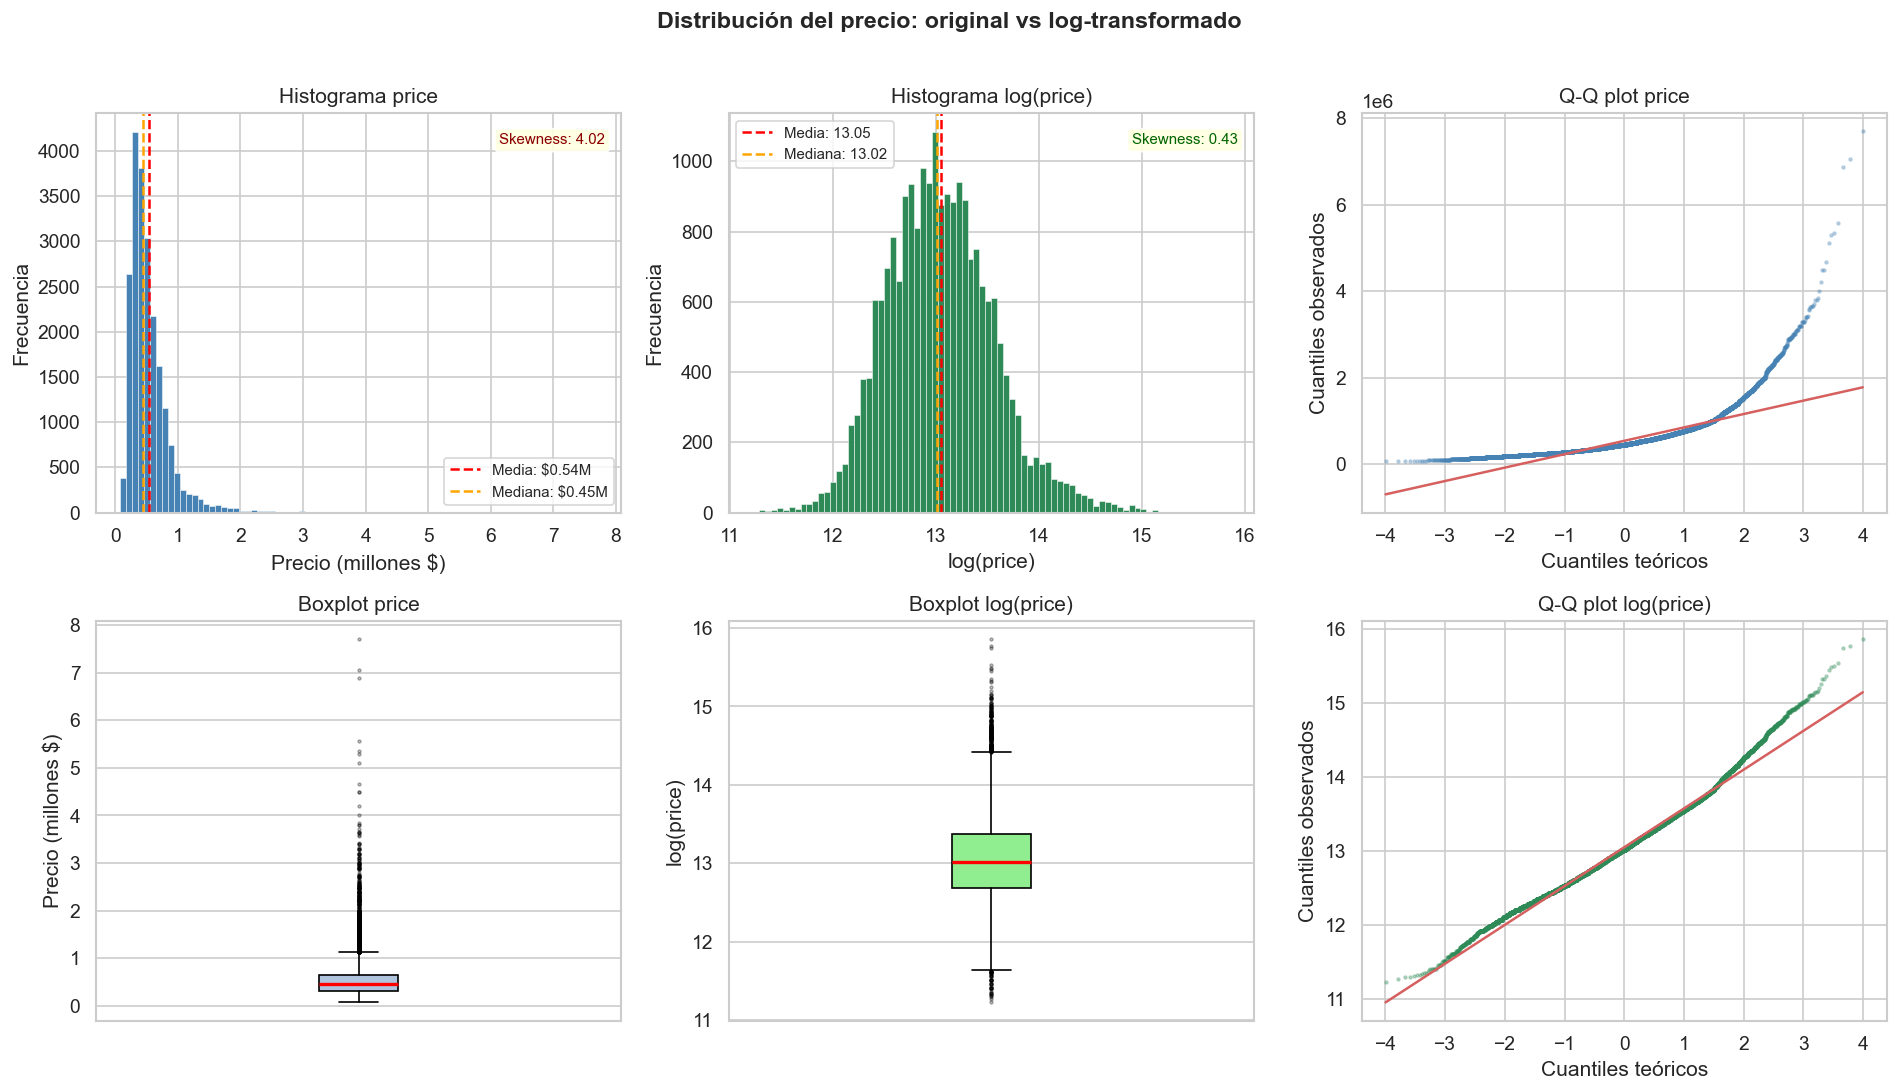

Skewness price: 4.024  →  log(price): 0.428  (mejora: 3.60 puntos)


In [5]:
df['log_price'] = np.log(df['price'])

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribución del precio: original vs log-transformado', fontsize=14, fontweight='bold', y=1.01)

# --- Histograma precio original ---
ax = axes[0, 0]
ax.hist(df['price'] / 1e6, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(df['price'].mean()   / 1e6, color='red',    linestyle='--', label=f"Media: ${df['price'].mean()/1e6:.2f}M")
ax.axvline(df['price'].median() / 1e6, color='orange', linestyle='--', label=f"Mediana: ${df['price'].median()/1e6:.2f}M")
ax.set_xlabel('Precio (millones $)'); ax.set_ylabel('Frecuencia')
ax.set_title('Histograma price')
ax.legend(fontsize=9)
skew_orig = df['price'].skew()
ax.text(0.97, 0.95, f'Skewness: {skew_orig:.2f}', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='darkred',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9))

# --- Histograma log(price) ---
ax = axes[0, 1]
ax.hist(df['log_price'], bins=80, color='seagreen', edgecolor='white', linewidth=0.3)
ax.axvline(df['log_price'].mean(),   color='red',    linestyle='--', label=f"Media: {df['log_price'].mean():.2f}")
ax.axvline(df['log_price'].median(), color='orange', linestyle='--', label=f"Mediana: {df['log_price'].median():.2f}")
ax.set_xlabel('log(price)'); ax.set_ylabel('Frecuencia')
ax.set_title('Histograma log(price)')
ax.legend(fontsize=9)
skew_log = df['log_price'].skew()
ax.text(0.97, 0.95, f'Skewness: {skew_log:.2f}', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='darkgreen',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9))

# --- Q-Q plot precio original ---
ax = axes[0, 2]
(osm, osr), (slope, intercept, r) = stats.probplot(df['price'], dist='norm', fit=True)
ax.scatter(osm, osr, s=3, alpha=0.3, color='steelblue')
x_line = np.array([osm[0], osm[-1]])
ax.plot(x_line, slope * x_line + intercept, 'r-', lw=1.5)
ax.set_title('Q-Q plot price')
ax.set_xlabel('Cuantiles teóricos'); ax.set_ylabel('Cuantiles observados')

# --- Boxplot precio original ---
ax = axes[1, 0]
ax.boxplot(df['price'] / 1e6, vert=True, patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'),
           medianprops=dict(color='red', lw=2),
           flierprops=dict(marker='.', markersize=3, alpha=0.4))
ax.set_ylabel('Precio (millones $)'); ax.set_title('Boxplot price'); ax.set_xticks([])

# --- Boxplot log(price) ---
ax = axes[1, 1]
ax.boxplot(df['log_price'], vert=True, patch_artist=True,
           boxprops=dict(facecolor='lightgreen'),
           medianprops=dict(color='red', lw=2),
           flierprops=dict(marker='.', markersize=3, alpha=0.4))
ax.set_ylabel('log(price)'); ax.set_title('Boxplot log(price)'); ax.set_xticks([])

# --- Q-Q plot log(price) ---
ax = axes[1, 2]
(osm, osr), (slope, intercept, r) = stats.probplot(df['log_price'], dist='norm', fit=True)
ax.scatter(osm, osr, s=3, alpha=0.3, color='seagreen')
x_line = np.array([osm[0], osm[-1]])
ax.plot(x_line, slope * x_line + intercept, 'r-', lw=1.5)
ax.set_title('Q-Q plot log(price)')
ax.set_xlabel('Cuantiles teóricos'); ax.set_ylabel('Cuantiles observados')

plt.tight_layout()
plt.savefig(FIG_PATH + '01_price_distribution.png', bbox_inches='tight')
plt.show()
print(f'Skewness price: {skew_orig:.3f}  →  log(price): {skew_log:.3f}  (mejora: {abs(skew_orig - skew_log):.2f} puntos)')

---
## 5. Correlaciones con el precio

### Heatmap completo de correlaciones

La correlación de Pearson mide la relación **lineal** entre dos variables (rango −1 a +1). Nos interesa:
1. **Columna `log_price`**: cuáles son los predictores más correlacionados con el target
2. **Correlaciones entre predictores**: qué variables son redundantes entre sí (multicolinealidad)

Para los modelos de árbol (RF, XGBoost) la multicolinealidad no es un problema técnico, pero ayuda a entender el dataset. Comparamos las correlaciones con `price` y con `log_price` para ver si la transformación logarítmica cambia las relaciones.

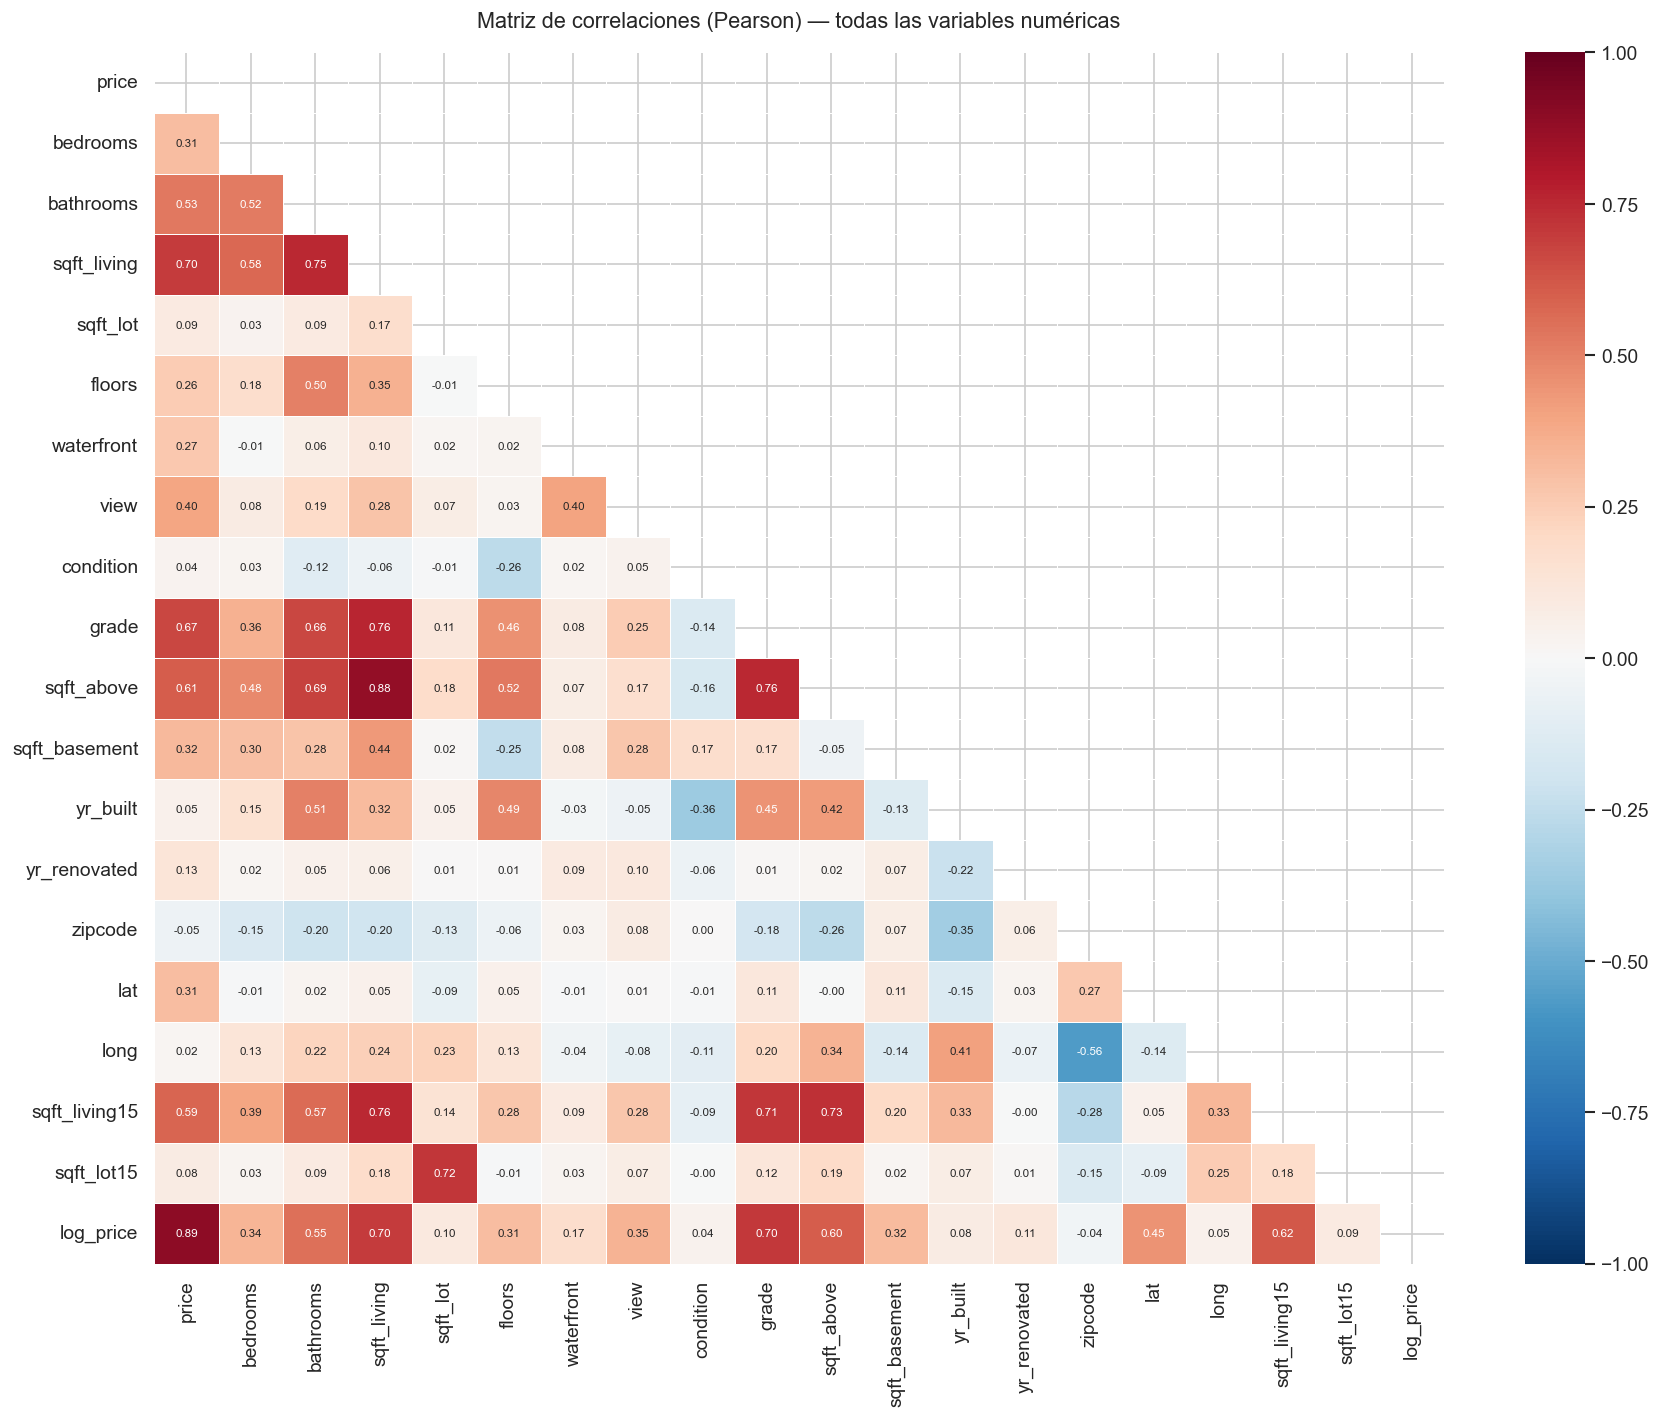

In [6]:
num_cols = df.select_dtypes(include='number').drop(columns=['id']).columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(15, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Solo triángulo inferior
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={'size': 7}, ax=ax
)
ax.set_title('Matriz de correlaciones (Pearson) — todas las variables numéricas', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(FIG_PATH + '02_heatmap_correlaciones.png', bbox_inches='tight')
plt.show()

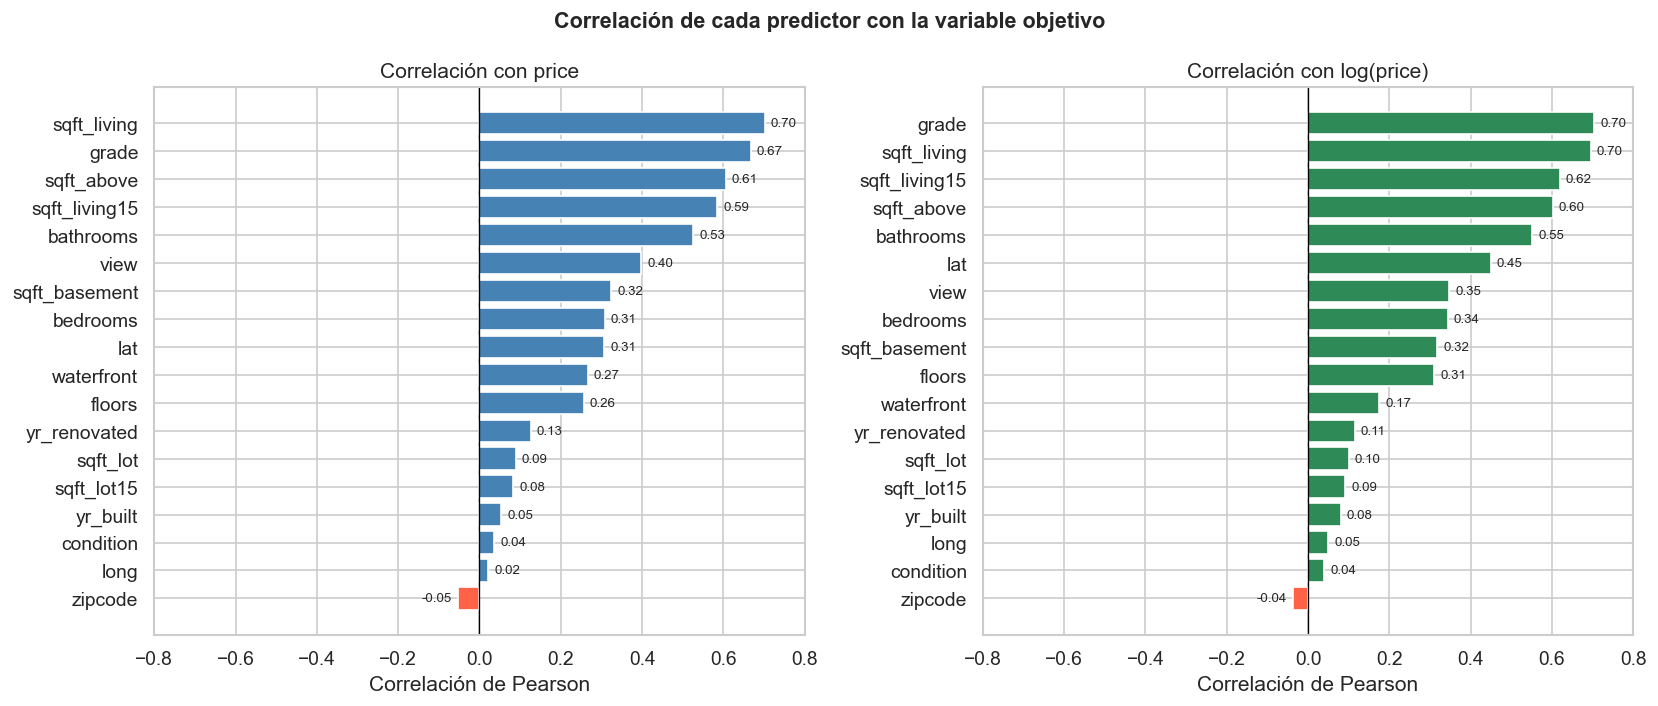

Top 5 correlaciones con log(price):
grade            0.703634
sqft_living      0.695341
sqft_living15    0.619312
sqft_above       0.601801
bathrooms        0.550802

Bottom 3 (negativas):
zipcode     -0.038306
condition    0.039558
long         0.049942


In [7]:
# Ranking de correlación con price y con log_price (side-by-side)
target_corr = df[num_cols].corr()[['price', 'log_price']].drop(['price', 'log_price'])
target_corr = target_corr.sort_values('log_price', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Correlación de cada predictor con la variable objetivo', fontsize=13, fontweight='bold')

for ax, col, color, title in zip(
    axes,
    ['price', 'log_price'],
    ['steelblue', 'seagreen'],
    ['Correlación con price', 'Correlación con log(price)']
):
    data_sorted = target_corr[col].sort_values()
    bar_colors  = [color if v >= 0 else 'tomato' for v in data_sorted]
    bars = ax.barh(data_sorted.index, data_sorted.values, color=bar_colors, edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Correlación de Pearson')
    ax.set_title(title)
    ax.set_xlim(-0.8, 0.8)
    for v, bar in zip(data_sorted.values, bars):
        offset = 0.015 if v >= 0 else -0.015
        ax.text(v + offset, bar.get_y() + bar.get_height()/2,
                f'{v:.2f}', va='center',
                ha='left' if v >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig(FIG_PATH + '03_correlacion_con_precio.png', bbox_inches='tight')
plt.show()

print('Top 5 correlaciones con log(price):')
print(target_corr['log_price'].sort_values(ascending=False).head(5).to_string())
print('\nBottom 3 (negativas):')
print(target_corr['log_price'].sort_values().head(3).to_string())

---
## 6. Variables de superficie (`sqft_*`)

`sqft_living` es sistemáticamente el predictor más fuerte del precio. En este bloque analizamos:

- **`sqft_living`**: superficie habitable total
- **`sqft_above`**: superficie sobre rasante
- **`sqft_basement`**: superficie del sótano (= sqft_living − sqft_above, redundante)
- **`sqft_lot`**: superficie total del terreno (mucha varianza, menor impacto en precio)
- **`sqft_living15`** y **`sqft_lot15`**: **spatial lags nativos** — medias de superficie de los 15 vecinos más cercanos ya calculadas por King County. Son la primera evidencia de que el entorno espacial importa. En el notebook 03 construiremos los nuestros con KNN sobre más variables.

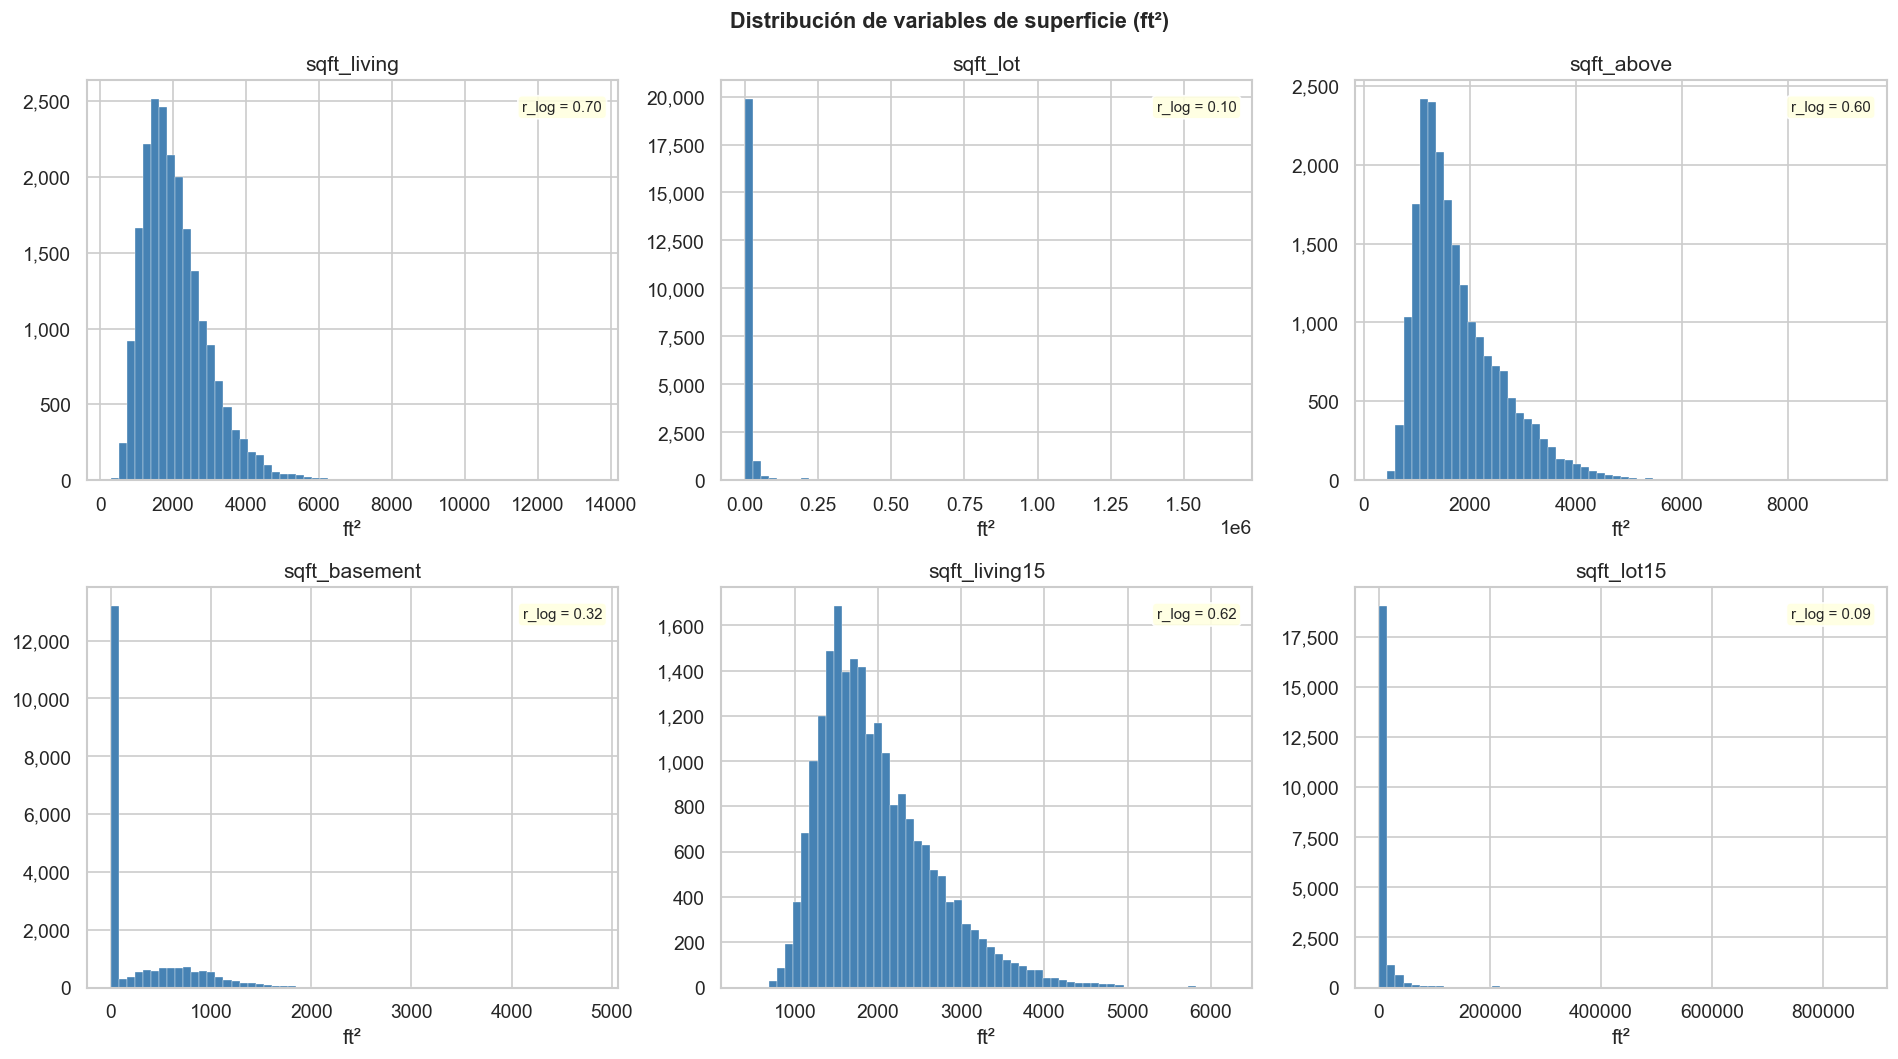

In [8]:
sqft_vars = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribución de variables de superficie (ft²)', fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), sqft_vars):
    r = df[col].corr(df['log_price'])
    ax.hist(df[col], bins=60, color='steelblue', edgecolor='white', linewidth=0.2)
    ax.set_title(col)
    ax.set_xlabel('ft²')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.text(0.97, 0.95, f'r_log = {r:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.savefig(FIG_PATH + '04_distribucion_sqft.png', bbox_inches='tight')
plt.show()

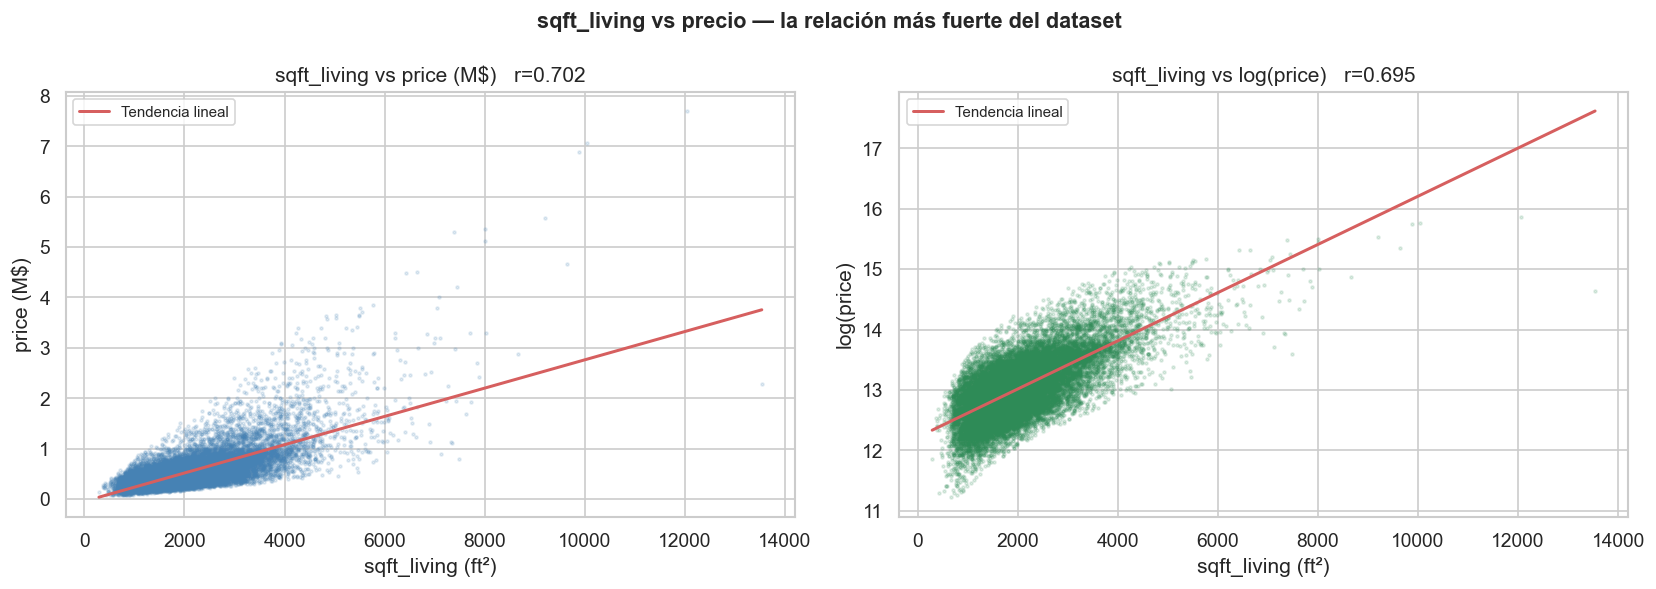

sqft_living = sqft_above + sqft_basement: 100.0% de los casos
→ sqft_basement es totalmente derivable de sqft_living y sqft_above (redundante)


In [9]:
# Scatter sqft_living vs precio: comparativa original vs log
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('sqft_living vs precio — la relación más fuerte del dataset', fontsize=13, fontweight='bold')

for ax, y_col, y_label, color in [
    (axes[0], df['price']/1e6, 'price (M$)',  'steelblue'),
    (axes[1], df['log_price'], 'log(price)',  'seagreen')
]:
    ax.scatter(df['sqft_living'], y_col, s=3, alpha=0.15, color=color)
    m, b = np.polyfit(df['sqft_living'], y_col, 1)
    x_l  = np.linspace(df['sqft_living'].min(), df['sqft_living'].max(), 200)
    ax.plot(x_l, m * x_l + b, 'r-', lw=1.8, label='Tendencia lineal')
    r = df['sqft_living'].corr(y_col)
    ax.set_xlabel('sqft_living (ft²)'); ax.set_ylabel(y_label)
    ax.set_title(f'sqft_living vs {y_label}   r={r:.3f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_PATH + '05_sqft_living_vs_price.png', bbox_inches='tight')
plt.show()

# Verificación redundancia sqft_basement
diff = (df['sqft_living'] - df['sqft_above'] - df['sqft_basement']).abs()
print(f'sqft_living = sqft_above + sqft_basement: {(diff == 0).mean()*100:.1f}% de los casos')
print('→ sqft_basement es totalmente derivable de sqft_living y sqft_above (redundante)')

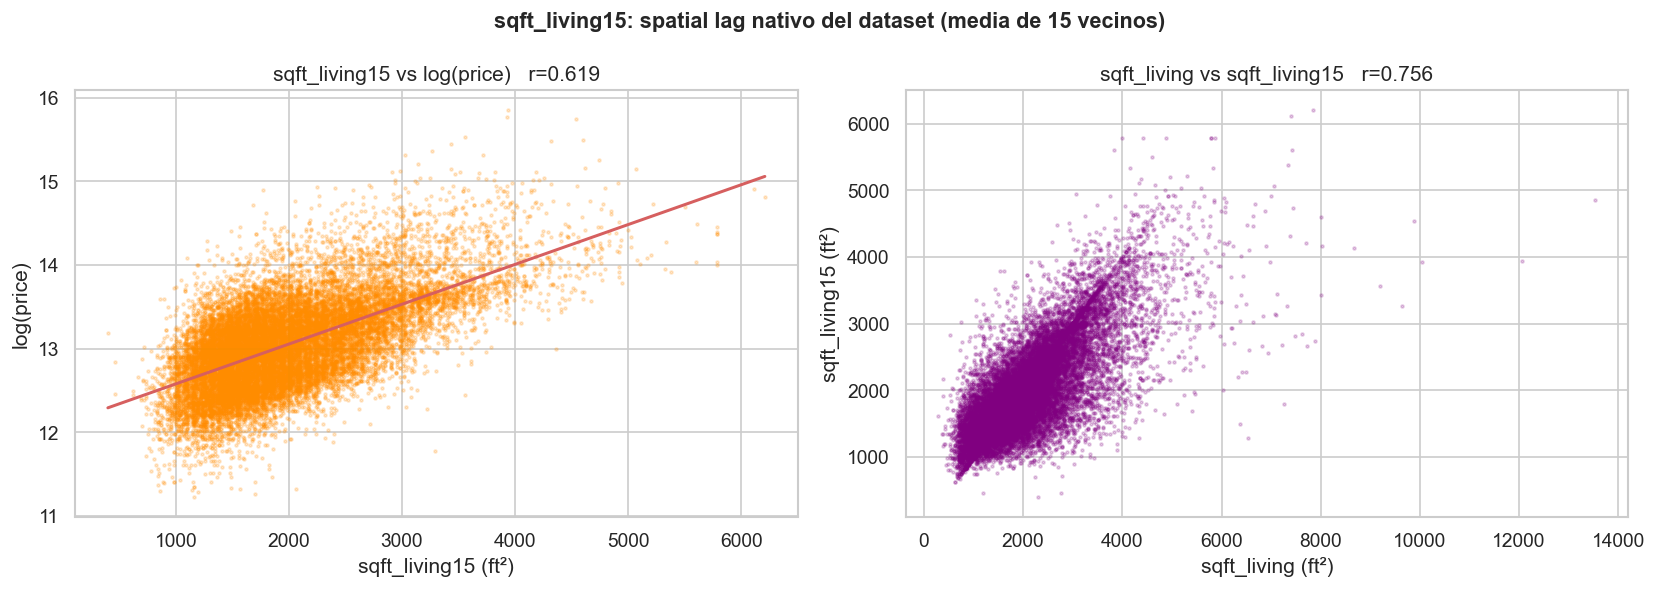

Interpretación: las casas grandes están rodeadas de casas grandes (r=0.756).
El entorno espacial (sqft_living15) predice el precio (r=0.619).
→ Primera evidencia de autocorrelación espacial positiva. Se explotará en notebook 03.


In [10]:
# sqft_living15 como spatial lag nativo — evidencia de autocorrelación espacial
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('sqft_living15: spatial lag nativo del dataset (media de 15 vecinos)', fontsize=13, fontweight='bold')

r1 = df['sqft_living15'].corr(df['log_price'])
r2 = df['sqft_living'].corr(df['sqft_living15'])

axes[0].scatter(df['sqft_living15'], df['log_price'], s=3, alpha=0.2, color='darkorange')
m, b = np.polyfit(df['sqft_living15'], df['log_price'], 1)
x_l  = np.linspace(df['sqft_living15'].min(), df['sqft_living15'].max(), 200)
axes[0].plot(x_l, m*x_l+b, 'r-', lw=1.8)
axes[0].set_xlabel('sqft_living15 (ft²)'); axes[0].set_ylabel('log(price)')
axes[0].set_title(f'sqft_living15 vs log(price)   r={r1:.3f}')

axes[1].scatter(df['sqft_living'], df['sqft_living15'], s=3, alpha=0.2, color='purple')
axes[1].set_xlabel('sqft_living (ft²)'); axes[1].set_ylabel('sqft_living15 (ft²)')
axes[1].set_title(f'sqft_living vs sqft_living15   r={r2:.3f}')

plt.tight_layout()
plt.savefig(FIG_PATH + '06_spatial_lags_nativos.png', bbox_inches='tight')
plt.show()

print('Interpretación: las casas grandes están rodeadas de casas grandes (r={:.3f}).'.format(r2))
print('El entorno espacial (sqft_living15) predice el precio (r={:.3f}).'.format(r1))
print('→ Primera evidencia de autocorrelación espacial positiva. Se explotará en notebook 03.')

---
## 7. Variables de calidad y condición

- **`grade` (1–13)**: Escala propia de King County para calidad constructiva. El valor 7 es el estándar medio. Valores 1–3 son infraviviendas; 11–13 son mansiones de lujo. Es la segunda variable más correlacionada con el precio.
- **`condition` (1–5)**: Estado de conservación del inmueble. Tiene menos varianza explicativa que `grade`.
- **`view` (0–4)**: Calidad de las vistas panorámicas. 0 = sin vistas especiales; 4 = vistas excepcionales.
- **`waterfront`** (0/1): Variable binaria. Las casas con acceso directo al agua tienen una **prima enorme** sobre el precio mediano.

Los boxplots permiten ver si hay monotonicidad (más calidad → más precio) y cuánto se solapan las distribuciones.

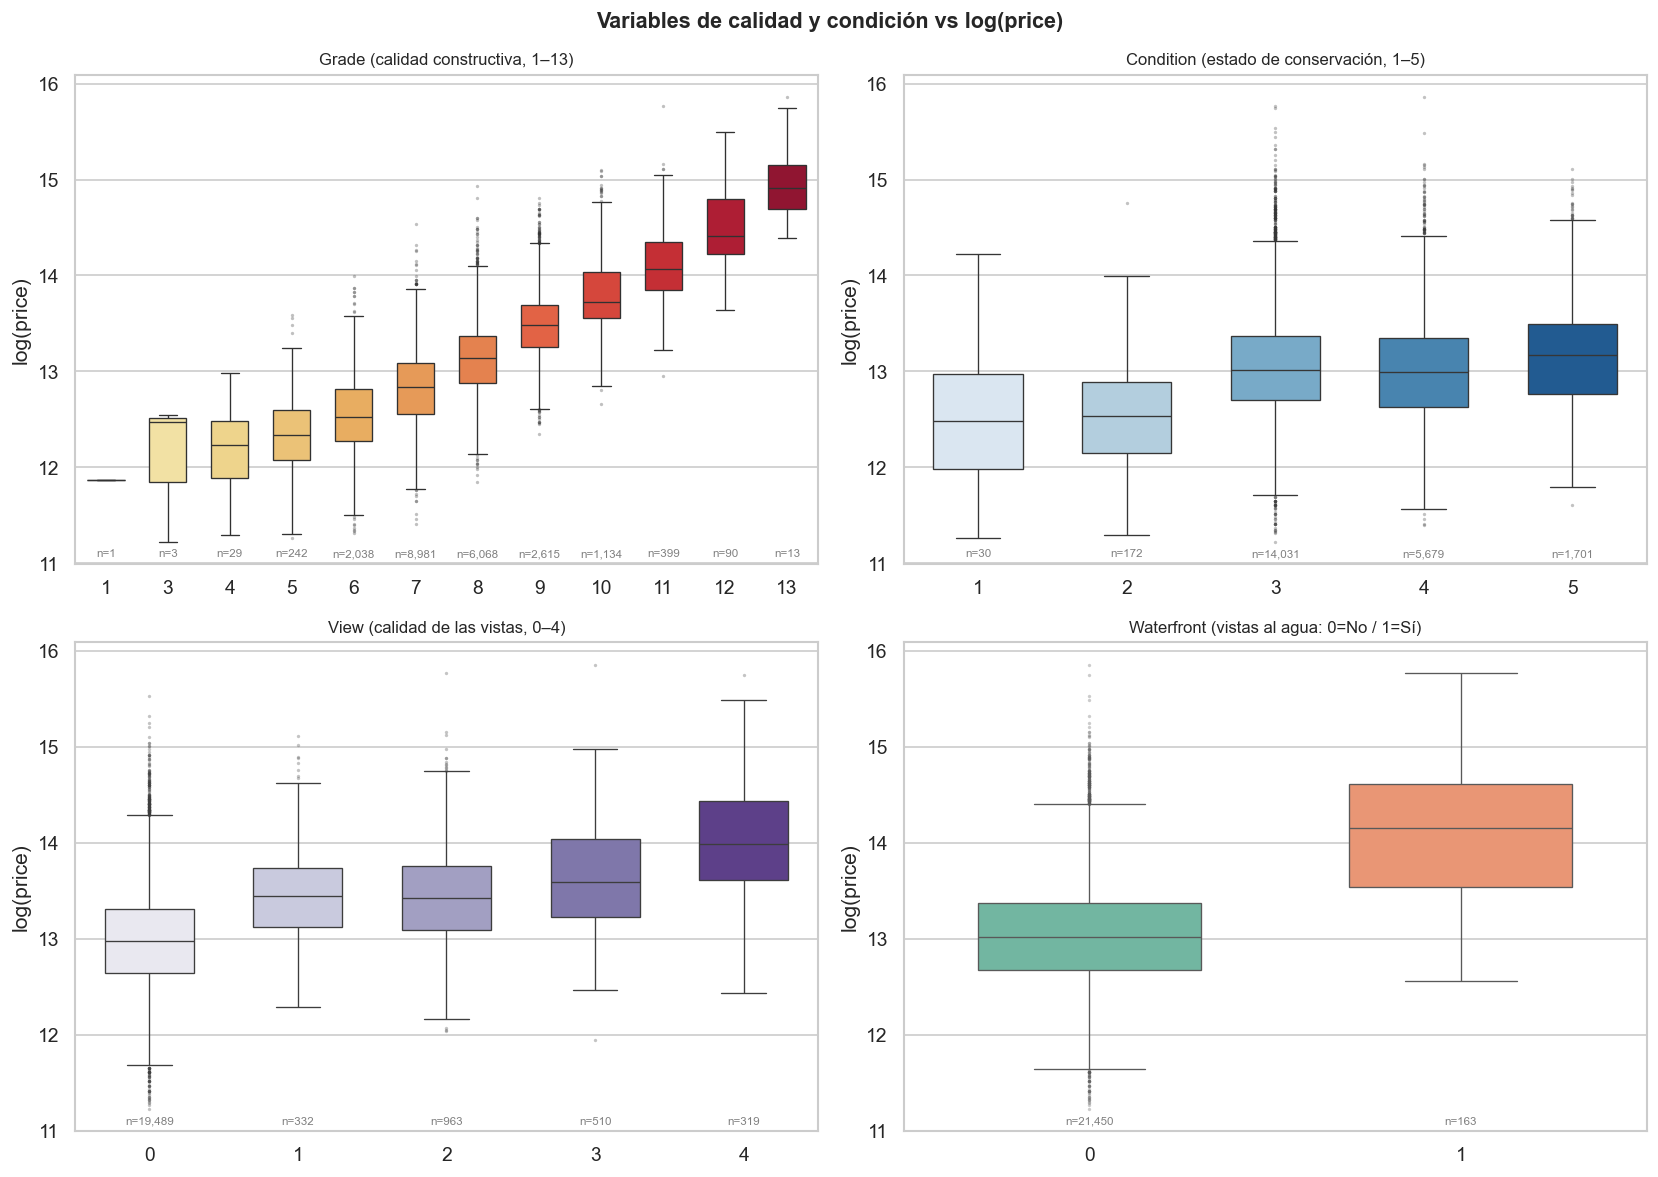

Prima waterfront: 450k$ (sin agua) vs 1400k$ (con agua) → +211%
Viviendas waterfront: 163 (0.8% del dataset)


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Variables de calidad y condición vs log(price)', fontsize=13, fontweight='bold')

configs = [
    ('grade',      'YlOrRd',  'Grade (calidad constructiva, 1–13)'),
    ('condition',  'Blues',   'Condition (estado de conservación, 1–5)'),
    ('view',       'Purples', 'View (calidad de las vistas, 0–4)'),
    ('waterfront', 'Set2',    'Waterfront (vistas al agua: 0=No / 1=Sí)'),
]

for ax, (col, pal, title) in zip(axes.flatten(), configs):
    order = sorted(df[col].unique())
    n_per_cat = df.groupby(col).size().reindex(order)

    sns.boxplot(
        data=df, x=col, y='log_price', order=order,
        palette=pal, ax=ax, width=0.6, linewidth=0.8,
        flierprops=dict(marker='.', markersize=2, alpha=0.3)
    )
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(''); ax.set_ylabel('log(price)')

    for i, (cat, n) in enumerate(zip(order, n_per_cat)):
        ax.text(i, ax.get_ylim()[0] + 0.05, f'n={n:,}',
                ha='center', va='bottom', fontsize=7, color='gray')

plt.tight_layout()
plt.savefig(FIG_PATH + '07_calidad_condicion.png', bbox_inches='tight')
plt.show()

# Prima waterfront
wf_median = df.groupby('waterfront')['price'].median()
prima = (wf_median[1] / wf_median[0] - 1) * 100
print(f"Prima waterfront: {wf_median[0]/1e3:.0f}k$ (sin agua) vs {wf_median[1]/1e3:.0f}k$ (con agua) → +{prima:.0f}%")
print(f"Viviendas waterfront: {(df['waterfront']==1).sum()} ({(df['waterfront']==1).mean()*100:.1f}% del dataset)")

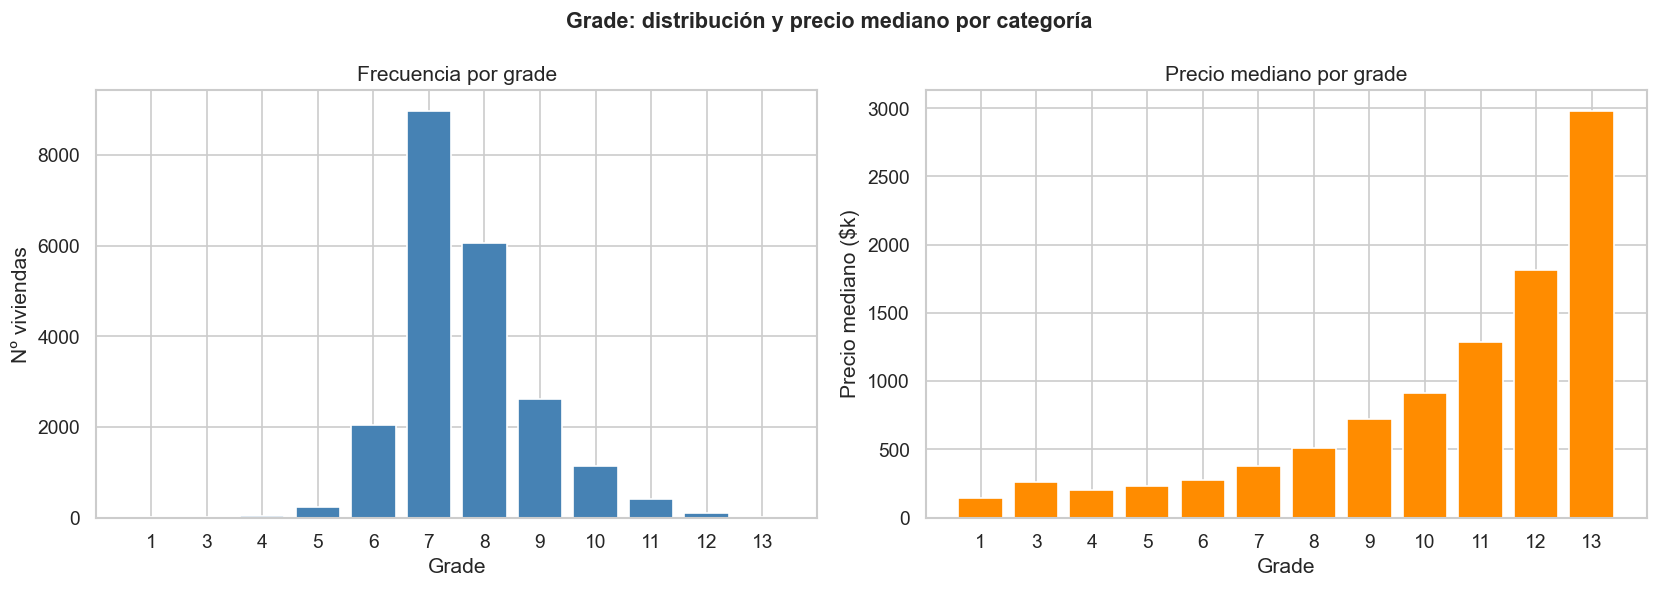

Ratio precio grade 13 vs grade 3: 21.0x


In [12]:
# Detalle grade: frecuencia + precio mediano
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Grade: distribución y precio mediano por categoría', fontsize=13, fontweight='bold')

grade_counts = df['grade'].value_counts().sort_index()
grade_price  = df.groupby('grade')['price'].median().sort_index() / 1e3

axes[0].bar(grade_counts.index.astype(str), grade_counts.values,
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Grade'); axes[0].set_ylabel('Nº viviendas')
axes[0].set_title('Frecuencia por grade')

axes[1].bar(grade_price.index.astype(str), grade_price.values,
            color='darkorange', edgecolor='white')
axes[1].set_xlabel('Grade'); axes[1].set_ylabel('Precio mediano ($k)')
axes[1].set_title('Precio mediano por grade')

plt.tight_layout()
plt.savefig(FIG_PATH + '08_grade_detalle.png', bbox_inches='tight')
plt.show()

ratio_grade = grade_price.max() / grade_price.min()
print(f'Ratio precio grade 13 vs grade 3: {ratio_grade:.1f}x')

---
## 8. Variables temporales: `yr_built`, `yr_renovated` y `date`

### `yr_built`
Las casas del dataset van de 1900 a 2015. La relación con el precio no es lineal: las casas muy antiguas pueden ser caras (históricas, bien ubicadas) o baratas. La correlación global es baja.

### `yr_renovated`
**El 95.8% de las viviendas tienen valor 0** (no renovadas). Tratarla como variable numérica continua no tiene sentido. Decisión de preprocessing: **binarizar a `renovated` (0/1)**. Un t-test confirma si hay diferencia significativa de precio entre renovadas y no renovadas.

### `date`
Las ventas van de mayo 2014 a mayo 2015. Extraemos el mes para capturar posible estacionalidad: en muchos mercados inmobiliarios la primavera concentra más ventas y a precios ligeramente superiores.

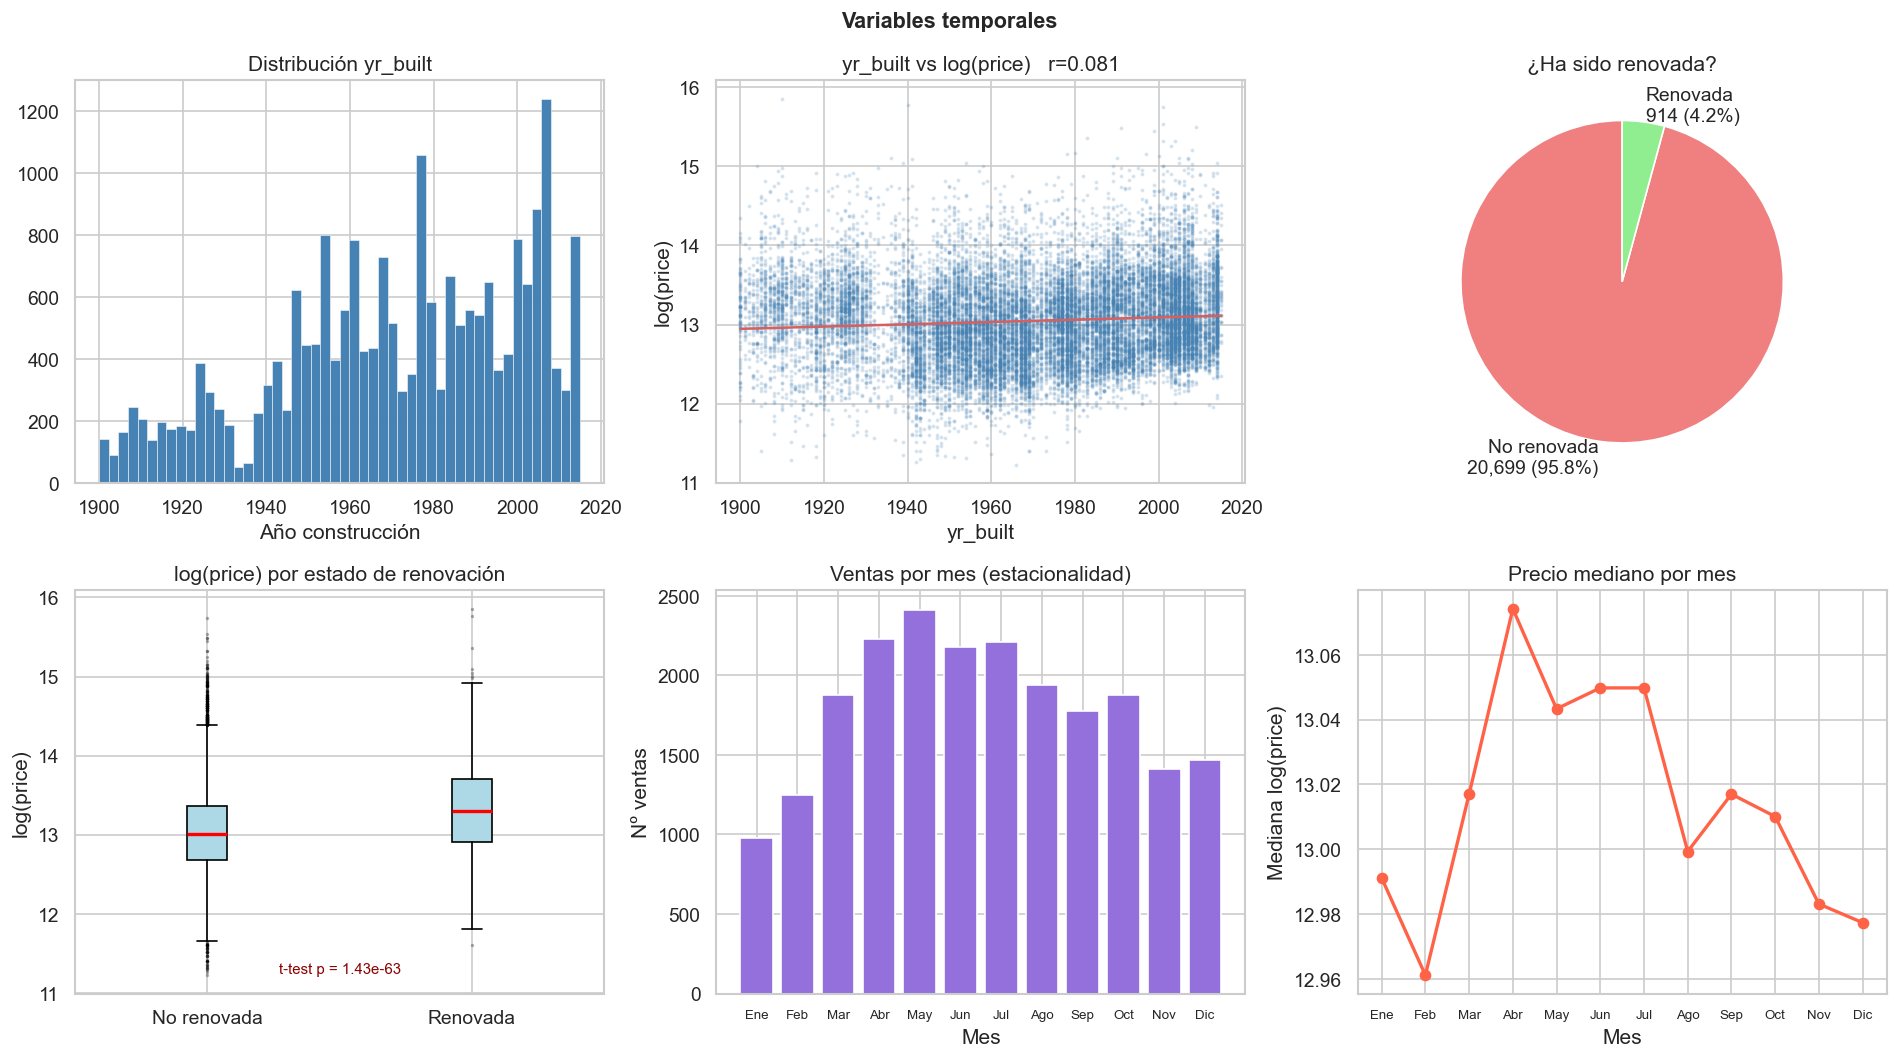

Viviendas renovadas: 914 (4.2%)
t-test renovada vs no renovada: t=-16.89, p=1.43e-63 → diferencia estadísticamente significativa


In [13]:
df['date_parsed'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')
df['sale_month']  = df['date_parsed'].dt.month
df['sale_year']   = df['date_parsed'].dt.year
df['renovated']   = (df['yr_renovated'] > 0).astype(int)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Variables temporales', fontsize=13, fontweight='bold')

# yr_built histograma
axes[0, 0].hist(df['yr_built'], bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0, 0].set_xlabel('Año construcción'); axes[0, 0].set_title('Distribución yr_built')

# yr_built vs log_price
axes[0, 1].scatter(df['yr_built'], df['log_price'], s=2, alpha=0.15, color='steelblue')
m, b = np.polyfit(df['yr_built'], df['log_price'], 1)
x_l  = np.linspace(df['yr_built'].min(), df['yr_built'].max(), 200)
axes[0, 1].plot(x_l, m*x_l+b, 'r-', lw=1.5)
r = df['yr_built'].corr(df['log_price'])
axes[0, 1].set_xlabel('yr_built'); axes[0, 1].set_ylabel('log(price)')
axes[0, 1].set_title(f'yr_built vs log(price)   r={r:.3f}')

# Pastel yr_renovated
renovadas  = df['renovated'].sum()
no_renov   = len(df) - renovadas
axes[0, 2].pie(
    [no_renov, renovadas],
    labels=[f'No renovada\n{no_renov:,} ({no_renov/len(df)*100:.1f}%)',
            f'Renovada\n{renovadas:,} ({renovadas/len(df)*100:.1f}%)'],
    colors=['lightcoral', 'lightgreen'], startangle=90,
    wedgeprops=dict(edgecolor='white')
)
axes[0, 2].set_title('¿Ha sido renovada?')

# Boxplot precio según renovación
renov_data = [df[df['renovated']==0]['log_price'], df[df['renovated']==1]['log_price']]
axes[1, 0].boxplot(renov_data, labels=['No renovada', 'Renovada'],
                   patch_artist=True,
                   boxprops=dict(facecolor='lightblue'),
                   medianprops=dict(color='red', lw=2),
                   flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[1, 0].set_ylabel('log(price)'); axes[1, 0].set_title('log(price) por estado de renovación')
t_stat, p_val = stats.ttest_ind(renov_data[0], renov_data[1])
axes[1, 0].text(0.5, 0.05, f't-test p = {p_val:.2e}',
                transform=axes[1,0].transAxes, ha='center', fontsize=9, color='darkred')

# Ventas por mes
monthly = df['sale_month'].value_counts().sort_index()
month_labels = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
axes[1, 1].bar(monthly.index, monthly.values, color='mediumpurple', edgecolor='white')
axes[1, 1].set_xlabel('Mes'); axes[1, 1].set_ylabel('Nº ventas')
axes[1, 1].set_xticks(range(1,13)); axes[1, 1].set_xticklabels(month_labels, fontsize=8)
axes[1, 1].set_title('Ventas por mes (estacionalidad)')

# Precio mediano por mes
monthly_price = df.groupby('sale_month')['log_price'].median()
axes[1, 2].plot(monthly_price.index, monthly_price.values, 'o-', color='tomato', lw=2, markersize=6)
axes[1, 2].set_xlabel('Mes'); axes[1, 2].set_ylabel('Mediana log(price)')
axes[1, 2].set_xticks(range(1,13)); axes[1, 2].set_xticklabels(month_labels, fontsize=8)
axes[1, 2].set_title('Precio mediano por mes')

plt.tight_layout()
plt.savefig(FIG_PATH + '09_variables_temporales.png', bbox_inches='tight')
plt.show()

print(f'Viviendas renovadas: {renovadas:,} ({renovadas/len(df)*100:.1f}%)')
print(f't-test renovada vs no renovada: t={t_stat:.2f}, p={p_val:.2e} → diferencia estadísticamente significativa')

---
## 9. Variables categóricas: `bedrooms`, `bathrooms`, `floors`

- **`bedrooms`**: moda en 3. Tiene un outlier obvio en 33 (se analiza en detalle en la sección de outliers).
- **`bathrooms`**: usa fracciones — 0.75 significa baño sin bañera; 1.0 = bañera completa. Muchos valores posibles pero relación monótona con el precio hasta cierto punto.
- **`floors`**: pocas categorías únicas (1.0, 1.5, 2.0, 2.5, 3.0, 3.5). Los valores .5 indican plantas parciales o buhardillas.

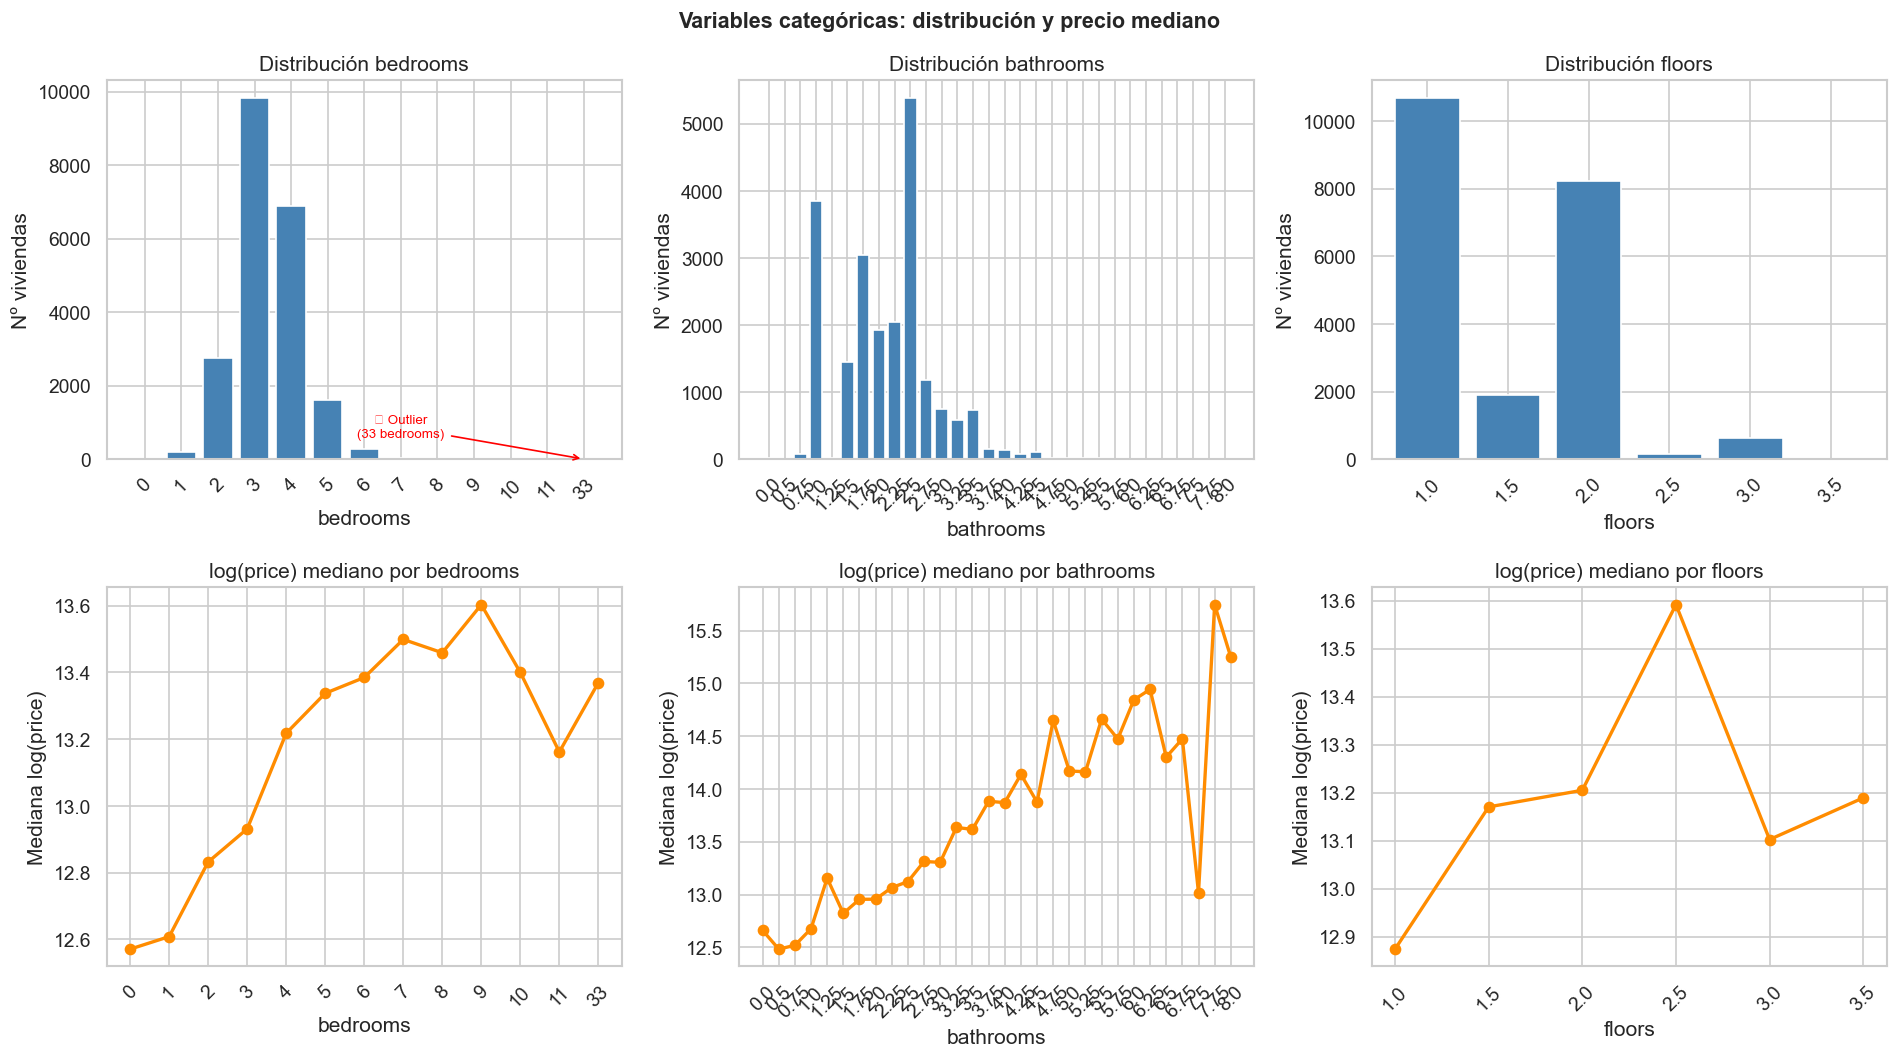

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Variables categóricas: distribución y precio mediano', fontsize=13, fontweight='bold')

cat_cols = ['bedrooms', 'bathrooms', 'floors']

for i, col in enumerate(cat_cols):
    order   = sorted(df[col].unique())
    counts  = df[col].value_counts().reindex(order)
    medians = df.groupby(col)['log_price'].median().reindex(order)

    # Fila 0: frecuencia
    bar_colors = ['tomato' if x == 33 else 'steelblue' for x in order]
    axes[0, i].bar([str(x) for x in order], counts.values,
                   color=bar_colors if col=='bedrooms' else 'steelblue', edgecolor='white')
    axes[0, i].set_title(f'Distribución {col}')
    axes[0, i].set_xlabel(col); axes[0, i].set_ylabel('Nº viviendas')
    axes[0, i].tick_params(axis='x', rotation=45)

    # Fila 1: precio mediano
    axes[1, i].plot([str(x) for x in order], medians.values,
                    'o-', color='darkorange', lw=2, markersize=6)
    axes[1, i].set_xlabel(col); axes[1, i].set_ylabel('Mediana log(price)')
    axes[1, i].set_title(f'log(price) mediano por {col}')
    axes[1, i].tick_params(axis='x', rotation=45)

# Anotar el outlier 33 bedrooms
order_bed = [str(x) for x in sorted(df['bedrooms'].unique())]
if '33' in order_bed:
    pos = order_bed.index('33')
    axes[0, 0].annotate(
        '⚠ Outlier\n(33 bedrooms)', xy=(pos, 1), xytext=(pos - 5, 600),
        fontsize=8, color='red', ha='center',
        arrowprops=dict(arrowstyle='->', color='red')
    )

plt.tight_layout()
plt.savefig(FIG_PATH + '10_categoricas.png', bbox_inches='tight')
plt.show()

---
## 10. Los archivos espaciales: qué son y para qué sirven

La carpeta `data/spatial/` contiene dos tipos de datos geoespaciales en formato **Shapefile** (`.shp`). Un shapefile es el estándar del sector GIS para almacenar geometrías + atributos. Viene en varios archivos auxiliares:
- `.shp` — las geometrías (coordenadas de los bordes o puntos)
- `.dbf` — los atributos (como un CSV)
- `.shx` — índice espacial
- `.prj` — sistema de coordenadas (aquí EPSG:4326 = WGS84, el GPS estándar)

### `King_county_zip.shp` — **Polígonos de códigos postales**
85 polígonos que representan los límites geográficos de cada ZIP code del condado. Se usa para:
- Hacer mapas coropléticos (colorear cada ZIP según precio medio)
- Construir matrices de contigüidad (ZIP vecinos comparten borde) para el modelo SLX del Módulo 2

### `kc_house.shp` — **Puntos de viviendas**
Cada una de las 21.613 viviendas del dataset convertida a un punto geográfico (columna `geometry = POINT(long, lat)`). Contiene las mismas columnas que el CSV. Se usa para:
- Visualizar las viviendas en un mapa real
- Calcular **matrices KNN** (los K vecinos geográficos más cercanos de cada casa)
- Construir los **spatial lags del notebook 03**: por cada vivienda calculamos la media del precio de sus K vecinos y la añadimos como feature nueva

In [15]:
# Cargar y explorar los shapefiles
gdf_zip    = gpd.read_file(SPATIAL_ZIP)
gdf_houses = gpd.read_file(SPATIAL_PTS)

gdf_zip['ZIP'] = gdf_zip['ZIP'].astype(int)

print('=== King_county_zip.shp (polígonos de ZIP codes) ===')
print(f'  Filas: {len(gdf_zip)} polígonos  |  CRS: {gdf_zip.crs}')
print(f'  Columnas: {list(gdf_zip.columns)}')
display(gdf_zip[['ZIP','COUNTY','ZIP_TYPE','Shape_Area']].head())

print()
print('=== kc_house.shp (puntos de viviendas) ===')
print(f'  Filas: {len(gdf_houses)} puntos  |  CRS: {gdf_houses.crs}')
print(f'  Columnas: {list(gdf_houses.columns)}')
display(gdf_houses[['id','price','sqft_liv','grade','geometry']].head())

=== King_county_zip.shp (polígonos de ZIP codes) ===
  Filas: 85 polígonos  |  CRS: EPSG:4326
  Columnas: ['OBJECTID', 'ZIP', 'COUNTY', 'ZIP_TYPE', 'Shape_Leng', 'Shape_Area', 'geometry']


,ZIP,COUNTY,ZIP_TYPE,Shape_Area
0,98031,33.0,Standard,2.280129e+08
1,98032,33.0,Standard,4.826754e+08
2,98033,33.0,Standard,2.566747e+08
3,98034,33.0,Standard,2.725072e+08
4,98030,33.0,Standard,2.000954e+08



=== kc_house.shp (puntos de viviendas) ===
  Filas: 21613 puntos  |  CRS: EPSG:4326
  Columnas: ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_liv', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basmt', 'yr_built', 'yr_renov', 'zipcode', 'lat', 'long', 'sqft_liv15', 'sqft_lot15', 'geometry']


,id,price,sqft_liv,grade,geometry
0,7.129301e+09,221900.0,1180.0,7.0,POINT (-122.25700 47.51120)
1,6.414100e+09,538000.0,2570.0,7.0,POINT (-122.31900 47.72100)
2,5.631500e+09,180000.0,770.0,6.0,POINT (-122.23300 47.73790)
3,2.487201e+09,604000.0,1960.0,7.0,POINT (-122.39300 47.52080)
4,1.954401e+09,510000.0,1680.0,8.0,POINT (-122.04500 47.61680)


---
## 11. Variación de precio por zipcode

El código postal es el proxy de barrio más directo del dataset. Si hay mucha diferencia de precio entre ZIPs, el modelo necesita capturar esa variación — bien usando `zipcode` directamente como feature (con encoding adecuado) o bien con coordenadas lat/long continuas.

El estadístico η² (eta-cuadrado) del ANOVA one-way mide qué porcentaje de la varianza total de `log(price)` queda explicada solo por saber el ZIP code.

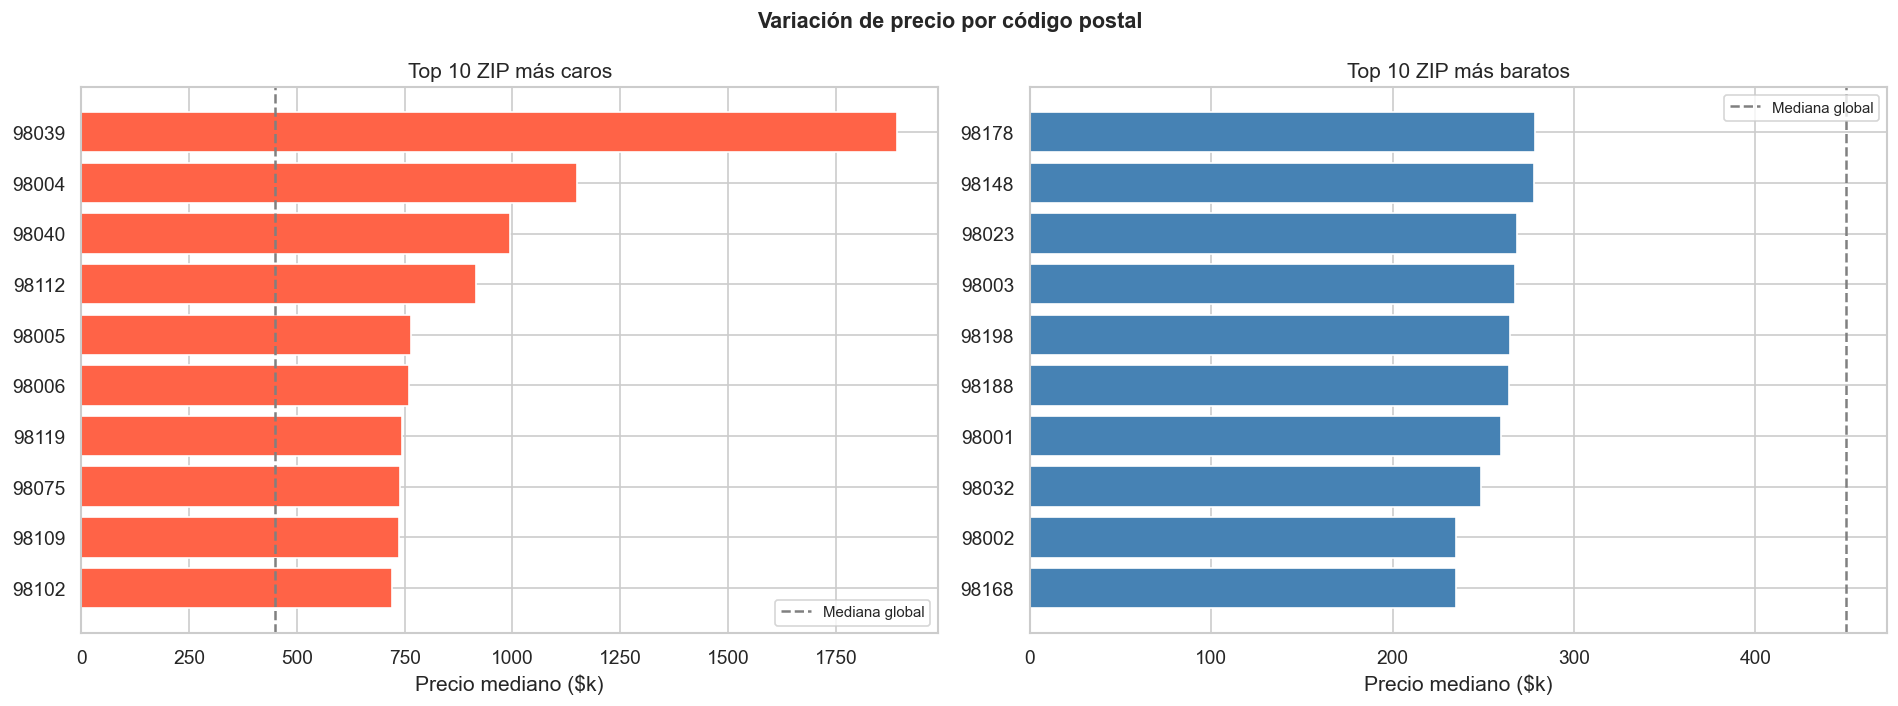

El ZIP más caro (98039) tiene mediana 1892k$
El ZIP más barato (98168) tiene mediana 235k$
Ratio: 8.1x — el ZIP explica mucha varianza


In [16]:
zip_stats = df.groupby('zipcode').agg(
    mediana_price=('price', 'median'),
    n=('price', 'count')
).sort_values('mediana_price', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Variación de precio por código postal', fontsize=13, fontweight='bold')

top10 = zip_stats.head(10)[::-1]
bot10 = zip_stats.tail(10)[::-1]

axes[0].barh([str(z) for z in top10.index], top10['mediana_price']/1e3,
             color='tomato', edgecolor='white')
axes[0].axvline(df['price'].median()/1e3, color='gray', linestyle='--', lw=1.5, label='Mediana global')
axes[0].set_xlabel('Precio mediano ($k)'); axes[0].set_title('Top 10 ZIP más caros')
axes[0].legend(fontsize=9)

axes[1].barh([str(z) for z in bot10.index], bot10['mediana_price']/1e3,
             color='steelblue', edgecolor='white')
axes[1].axvline(df['price'].median()/1e3, color='gray', linestyle='--', lw=1.5, label='Mediana global')
axes[1].set_xlabel('Precio mediano ($k)'); axes[1].set_title('Top 10 ZIP más baratos')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_PATH + '11_precio_por_zipcode.png', bbox_inches='tight')
plt.show()

ratio_zip = zip_stats['mediana_price'].max() / zip_stats['mediana_price'].min()
print(f'El ZIP más caro ({zip_stats.index[0]}) tiene mediana {zip_stats["mediana_price"].max()/1e3:.0f}k$')
print(f'El ZIP más barato ({zip_stats.index[-1]}) tiene mediana {zip_stats["mediana_price"].min()/1e3:.0f}k$')
print(f'Ratio: {ratio_zip:.1f}x — el ZIP explica mucha varianza')

In [17]:
# ANOVA one-way: cuánta varianza explica solo el zipcode
groups      = [grp['log_price'].values for _, grp in df.groupby('zipcode')]
f_stat, p_val = stats.f_oneway(*groups)

grand_mean  = df['log_price'].mean()
ss_between  = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
ss_total    = ((df['log_price'] - grand_mean)**2).sum()
eta2        = ss_between / ss_total

print('ANOVA log(price) ~ zipcode:')
print(f'  F-statistic = {f_stat:,.0f}')
print(f'  p-value     = {p_val:.2e}')
print(f'  η² (varianza explicada): {eta2:.3f} = {eta2*100:.1f}%')
print()
print(f'→ El zipcode solo explica el {eta2*100:.1f}% de la varianza del log(price)')
print('→ El resto lo capturan los atributos físicos + la posición continua (lat/long)')
print('→ lat/long añade la granularidad que el zipcode no tiene (diferencias dentro del mismo ZIP)')

ANOVA log(price) ~ zipcode:
  F-statistic = 352
  p-value     = 0.00e+00
  η² (varianza explicada): 0.530 = 53.0%

→ El zipcode solo explica el 53.0% de la varianza del log(price)
→ El resto lo capturan los atributos físicos + la posición continua (lat/long)
→ lat/long añade la granularidad que el zipcode no tiene (diferencias dentro del mismo ZIP)


---
## 12. Mapas geográficos: gradiente espacial del precio

Esta es la visualización más importante del TFM para justificar el módulo espacial. Los mapas muestran que:
- El precio **no se distribuye aleatoriamente** en el espacio
- Hay un cluster de precios altos en **Seattle centro** y las riberas del lago Washington / Lake Sammamish
- Esta estructura espacial es exactamente lo que los modelos SLX y los KNN lags intentan capturar

Si la localización no importara, los puntos del mapa estarían mezclados aleatoriamente sin patrón de color.

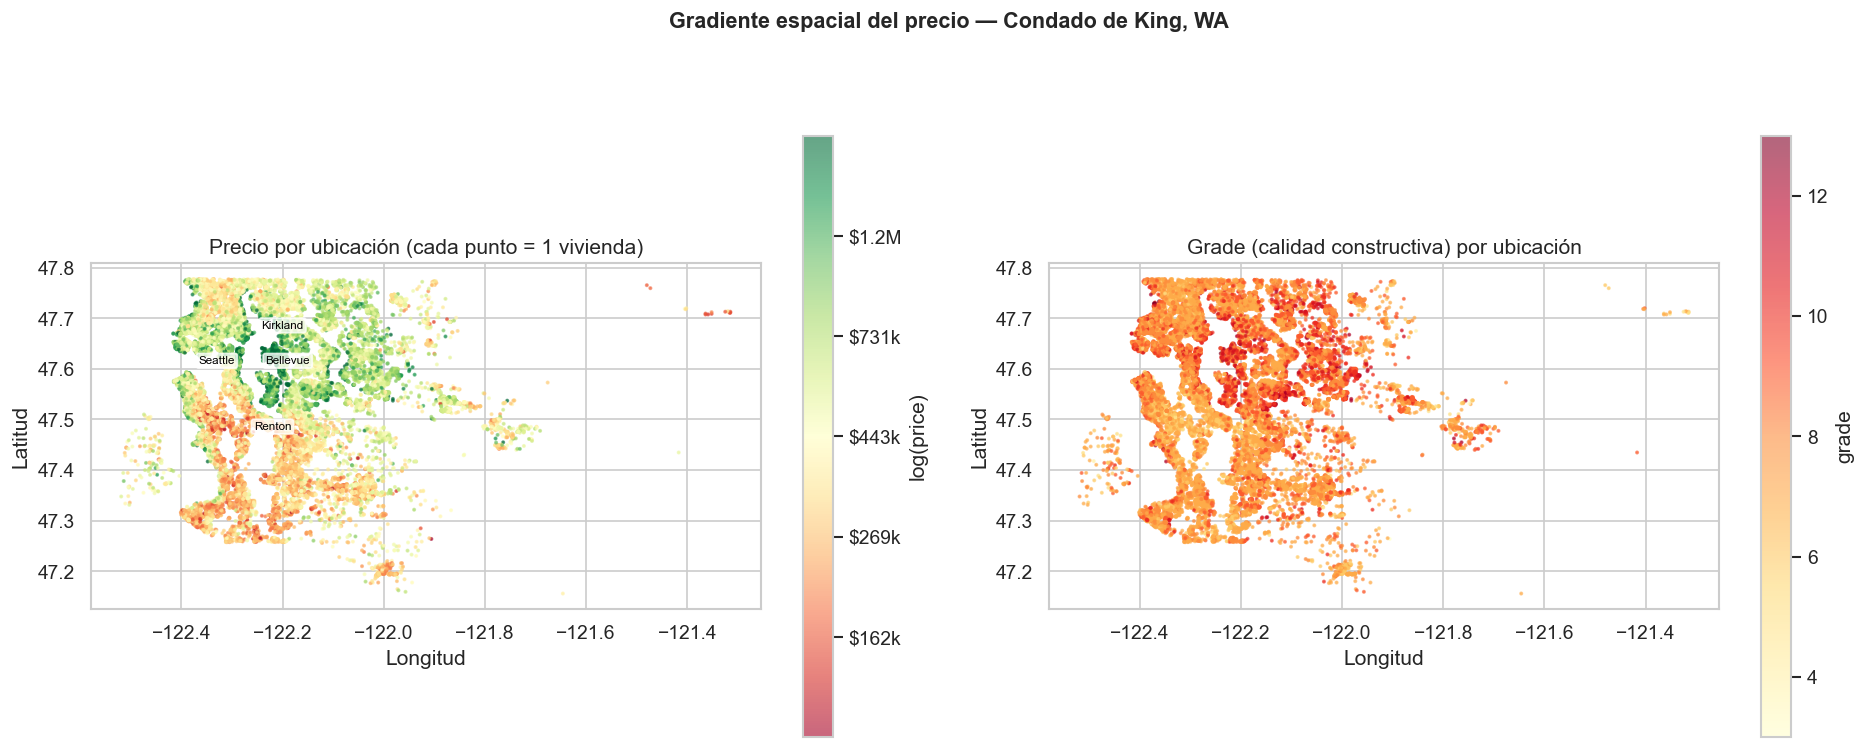

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Gradiente espacial del precio — Condado de King, WA', fontsize=13, fontweight='bold')

# Scatter lat/long coloreado por log(price)
sc = axes[0].scatter(
    df['long'], df['lat'], c=df['log_price'],
    cmap='RdYlGn', s=2, alpha=0.6, vmin=11.5, vmax=14.5
)
cb = plt.colorbar(sc, ax=axes[0], label='log(price)', shrink=0.8)
cb.set_ticks([12, 12.5, 13, 13.5, 14])
cb.set_ticklabels(['$162k', '$269k', '$443k', '$731k', '$1.2M'])
axes[0].set_xlabel('Longitud'); axes[0].set_ylabel('Latitud')
axes[0].set_title('Precio por ubicación (cada punto = 1 vivienda)')
axes[0].set_aspect('equal')
for label, xy in [('Seattle', (-122.33, 47.61)), ('Bellevue', (-122.19, 47.61)),
                  ('Renton', (-122.22, 47.48)),  ('Kirkland', (-122.20, 47.68))]:
    axes[0].annotate(label, xy=xy, fontsize=7, color='black', ha='center',
                     bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75))

# Scatter coloreado por grade
sc2 = axes[1].scatter(
    df['long'], df['lat'], c=df['grade'],
    cmap='YlOrRd', s=2, alpha=0.6, vmin=3, vmax=13
)
plt.colorbar(sc2, ax=axes[1], label='grade', shrink=0.8)
axes[1].set_xlabel('Longitud'); axes[1].set_ylabel('Latitud')
axes[1].set_title('Grade (calidad constructiva) por ubicación')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig(FIG_PATH + '12_mapa_scatter_precio.png', bbox_inches='tight')
plt.show()

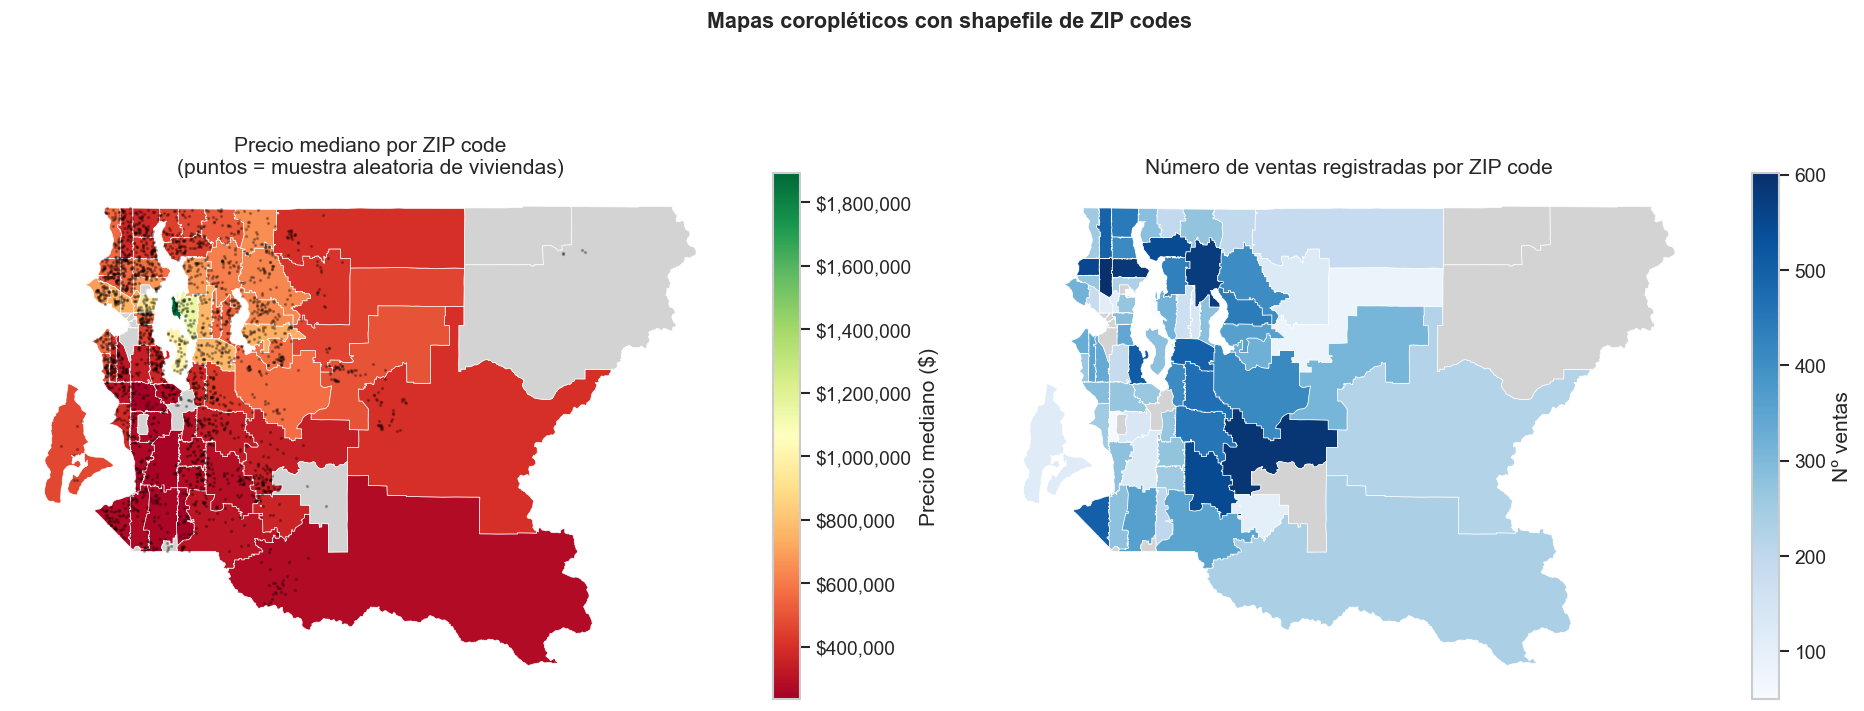

Shapefile ZIP: 85 polígonos  |  70 con datos de precio


In [19]:
# Mapa coroplético con polígonos de ZIP (shapefile King_county_zip)
zip_price = df.groupby('zipcode')['price'].median().reset_index()
zip_price.columns = ['ZIP', 'median_price']
gdf_map = gdf_zip.merge(zip_price, on='ZIP', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Mapas coropléticos con shapefile de ZIP codes', fontsize=13, fontweight='bold')

# Precio mediano por ZIP
gdf_map.plot(
    column='median_price', ax=axes[0], cmap='RdYlGn',
    legend=True,
    legend_kwds={'label': 'Precio mediano ($)', 'shrink': 0.7, 'format': '${x:,.0f}'},
    edgecolor='white', linewidth=0.4,
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'}
)
# Puntos de casas (muestra) superpuestos
sample = df.sample(2500, random_state=SEED)
axes[0].scatter(sample['long'], sample['lat'], s=1, alpha=0.25, color='black', zorder=2)
axes[0].set_title('Precio mediano por ZIP code\n(puntos = muestra aleatoria de viviendas)')
axes[0].set_axis_off()

# Nº de ventas por ZIP
zip_n = df.groupby('zipcode').size().reset_index(name='n')
zip_n.columns = ['ZIP', 'n']
gdf_map2 = gdf_zip.merge(zip_n, on='ZIP', how='left')
gdf_map2.plot(
    column='n', ax=axes[1], cmap='Blues',
    legend=True, legend_kwds={'label': 'Nº ventas', 'shrink': 0.7},
    edgecolor='white', linewidth=0.4, missing_kwds={'color': 'lightgrey'}
)
axes[1].set_title('Número de ventas registradas por ZIP code')
axes[1].set_axis_off()

plt.tight_layout()
plt.savefig(FIG_PATH + '13_mapa_coropletico_zip.png', bbox_inches='tight')
plt.show()

print(f'Shapefile ZIP: {len(gdf_zip)} polígonos  |  {gdf_map["median_price"].notna().sum()} con datos de precio')

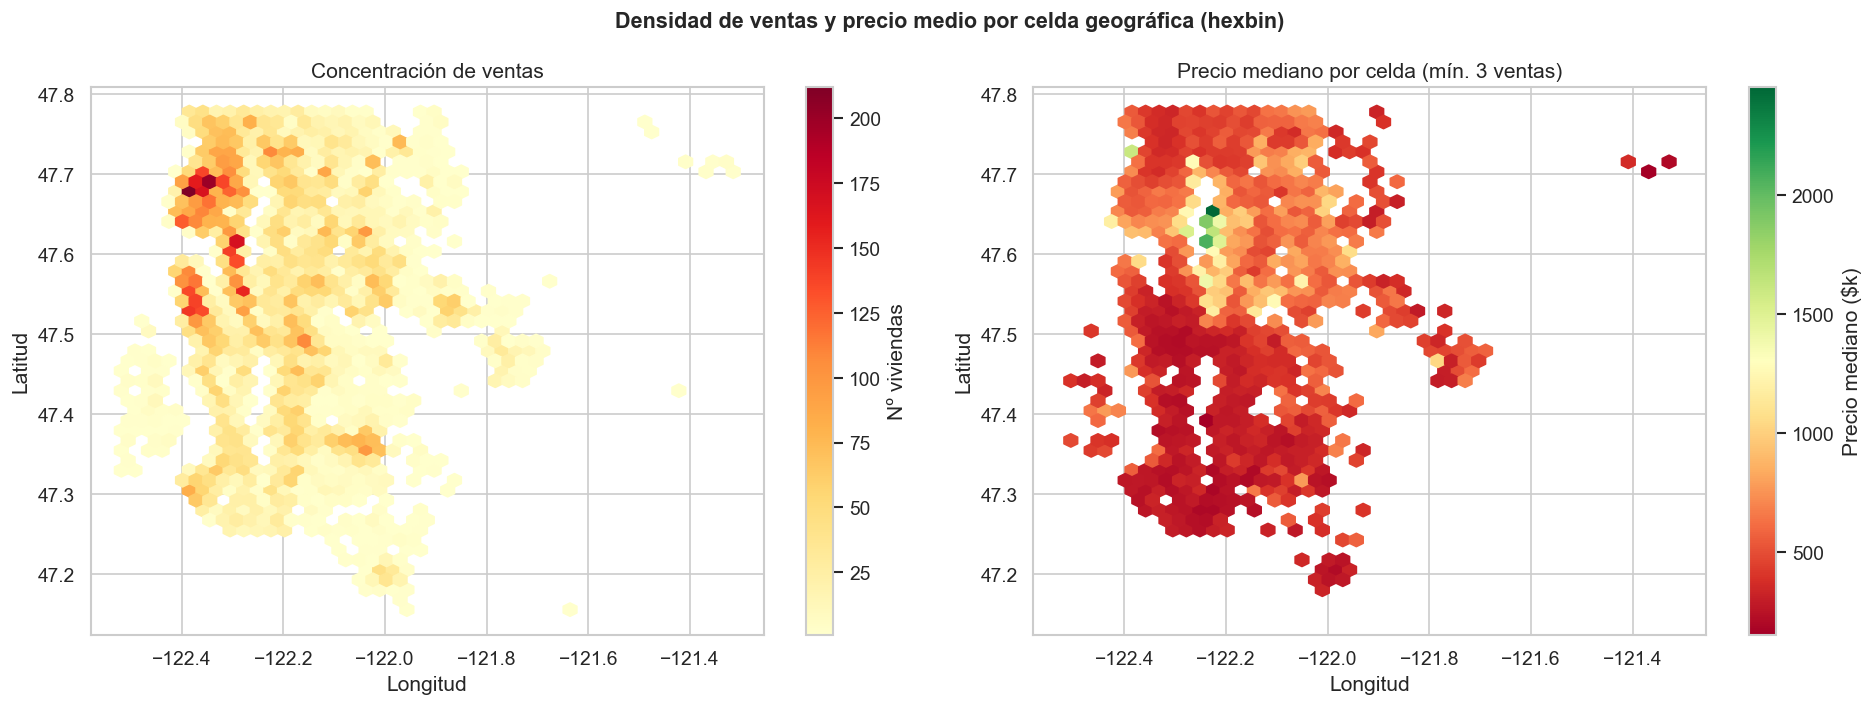

In [20]:
# Mapa hexbin: densidad de ventas y precio mediano por celda
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Densidad de ventas y precio medio por celda geográfica (hexbin)', fontsize=13, fontweight='bold')

hb1 = axes[0].hexbin(df['long'], df['lat'], gridsize=45, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb1, ax=axes[0], label='Nº viviendas')
axes[0].set_xlabel('Longitud'); axes[0].set_ylabel('Latitud')
axes[0].set_title('Concentración de ventas')

hb2 = axes[1].hexbin(df['long'], df['lat'], C=df['price']/1e3,
                     gridsize=45, reduce_C_function=np.median,
                     cmap='RdYlGn', mincnt=3)
plt.colorbar(hb2, ax=axes[1], label='Precio mediano ($k)')
axes[1].set_xlabel('Longitud'); axes[1].set_ylabel('Latitud')
axes[1].set_title('Precio mediano por celda (mín. 3 ventas)')

plt.tight_layout()
plt.savefig(FIG_PATH + '14_hexbin_densidad_precio.png', bbox_inches='tight')
plt.show()

---
## 13. Autocorrelación espacial: diagrama de Moran

La autocorrelación espacial es el fenómeno por el que **viviendas cercanas tienden a tener precios similares**. Para cuantificarla calculamos el **lag espacial**: el precio medio de los K vecinos más cercanos de cada vivienda.

El **diagrama de Moran** es el scatter plot de `log(price)` vs su lag espacial (ambos centrados). Una nube con pendiente positiva confirma autocorrelación positiva (casas caras rodeadas de caras). Los cuatro cuadrantes representan:
- **H-H** (rojo): viviendas con precio alto rodeadas de precio alto → clusters caros
- **L-L** (azul): precio bajo rodeado de precio bajo → clusters baratos
- **H-L** / **L-H**: valores atípicos espaciales (una casa cara en barrio barato, o viceversa)

La pendiente de la regresión en el diagrama de Moran es una aproximación al **Índice de Moran I**, que en el notebook 07 usaremos para evaluar si los residuos de los modelos siguen teniendo estructura espacial.

In [21]:
# Calcular spatial lag manual con BallTree (haversine para coordenadas GPS)
K = 10
coords_rad   = np.radians(df[['lat', 'long']].values)
tree         = BallTree(coords_rad, metric='haversine')
_, indices   = tree.query(coords_rad, k=K+1)  # k+1 porque el punto 0 es la propia vivienda

neighbor_idx           = indices[:, 1:]        # Excluir la propia vivienda
lag_log_price          = df['log_price'].values[neighbor_idx].mean(axis=1)
df['spatial_lag_log_price'] = lag_log_price

r_moran = np.corrcoef(df['log_price'], lag_log_price)[0, 1]
print(f'Correlación log(price) vs spatial_lag (K={K} vecinos más cercanos): r = {r_moran:.4f}')
print(f'→ Autocorrelación espacial muy alta: conocer el precio del entorno predice el precio propio')

Correlación log(price) vs spatial_lag (K=10 vecinos más cercanos): r = 0.8385
→ Autocorrelación espacial muy alta: conocer el precio del entorno predice el precio propio


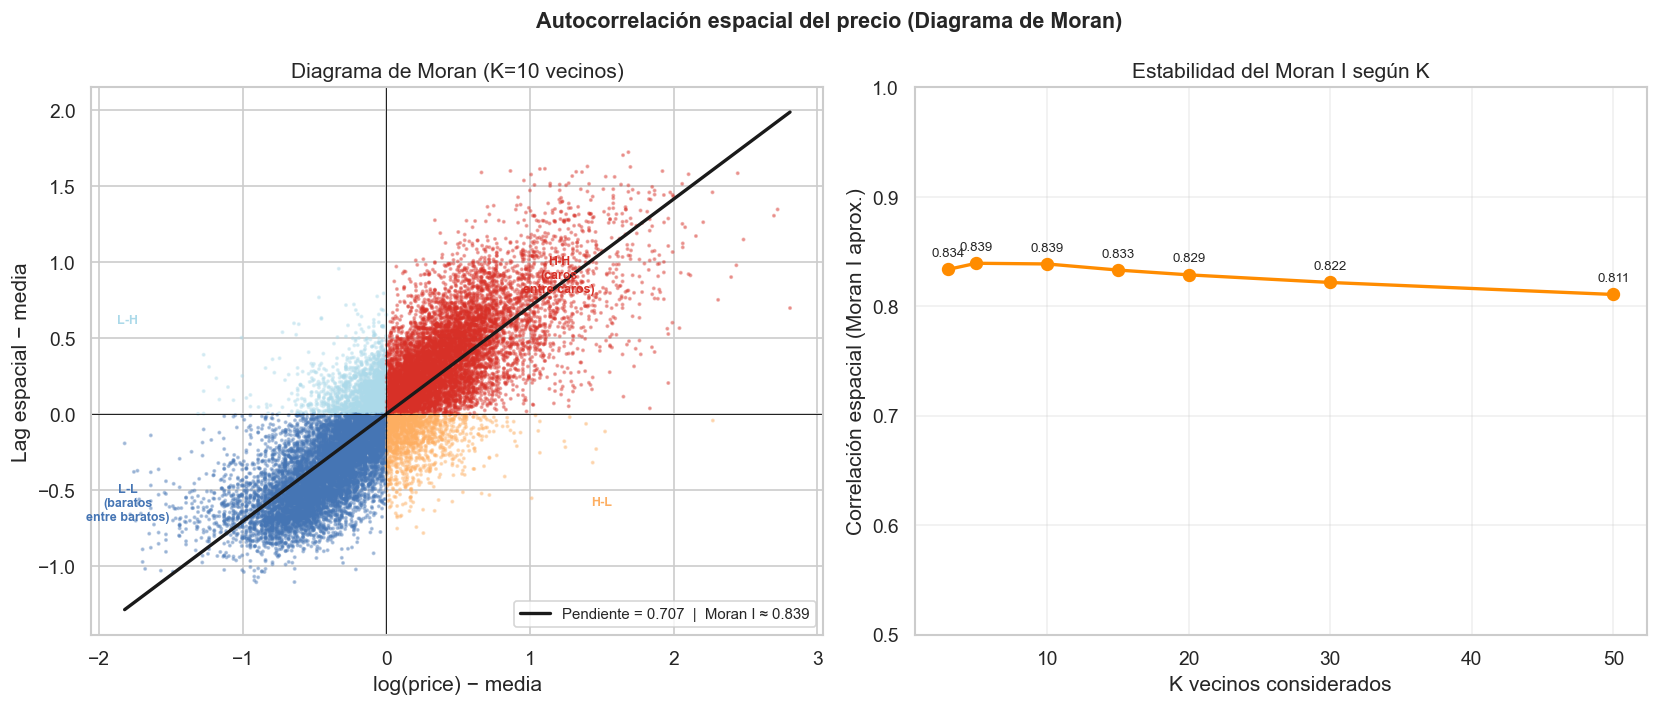

Moran I (K=10): 0.8385
→ Valor próximo a 1 indica autocorrelación espacial muy fuerte
→ Justifica el uso de KNN lags como features espaciales en el notebook 03


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Autocorrelación espacial del precio (Diagrama de Moran)', fontsize=13, fontweight='bold')

# Centrar variables
y_c  = df['log_price'] - df['log_price'].mean()
wy_c = lag_log_price   - lag_log_price.mean()

# Colores por cuadrante
HH = (y_c > 0) & (wy_c > 0)
LL = (y_c < 0) & (wy_c < 0)
HL = (y_c > 0) & (wy_c < 0)
LH = (y_c < 0) & (wy_c > 0)
c_arr = np.where(HH, '#d73027', np.where(LL, '#4575b4', np.where(HL, '#fdae61', '#abd9e9')))

axes[0].scatter(y_c, wy_c, c=c_arr, s=2, alpha=0.35)
m, b = np.polyfit(y_c, wy_c, 1)
x_l  = np.linspace(y_c.min(), y_c.max(), 200)
axes[0].plot(x_l, m*x_l+b, 'k-', lw=2,
             label=f'Pendiente = {m:.3f}  |  Moran I ≈ {r_moran:.3f}')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].axvline(0, color='black', lw=0.5)
axes[0].set_xlabel('log(price) − media'); axes[0].set_ylabel('Lag espacial − media')
axes[0].set_title(f'Diagrama de Moran (K={K} vecinos)')
axes[0].legend(fontsize=9)

# Leyenda de cuadrantes
for text, x, y, c in [
    ('H-H\n(caros\nentre caros)', 1.2, 0.8, '#d73027'),
    ('L-L\n(baratos\nentre baratos)', -1.8, -0.7, '#4575b4'),
    ('H-L', 1.5, -0.6, '#fdae61'),
    ('L-H', -1.8, 0.6, '#abd9e9')
]:
    axes[0].text(x, y, text, fontsize=7.5, color=c, ha='center', fontweight='bold')

# Evolución del Moran I para distintos K
ks     = [3, 5, 10, 15, 20, 30, 50]
morans = []
for k in ks:
    _, idx_k = tree.query(coords_rad, k=k+1)
    lag_k    = df['log_price'].values[idx_k[:, 1:]].mean(axis=1)
    morans.append(np.corrcoef(df['log_price'], lag_k)[0, 1])

axes[1].plot(ks, morans, 'o-', color='darkorange', lw=2, markersize=7)
axes[1].set_xlabel('K vecinos considerados')
axes[1].set_ylabel('Correlación espacial (Moran I aprox.)')
axes[1].set_title('Estabilidad del Moran I según K')
axes[1].set_ylim(0.5, 1.0)
axes[1].grid(True, alpha=0.3)
for k, m_val in zip(ks, morans):
    axes[1].annotate(f'{m_val:.3f}', xy=(k, m_val), xytext=(0, 8),
                     textcoords='offset points', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIG_PATH + '15_diagrama_moran.png', bbox_inches='tight')
plt.show()

print(f'Moran I (K=10): {r_moran:.4f}')
print('→ Valor próximo a 1 indica autocorrelación espacial muy fuerte')
print('→ Justifica el uso de KNN lags como features espaciales en el notebook 03')

---
## 14. Detección de outliers

### Outlier de `bedrooms` = 33

Una vivienda con 33 habitaciones y solo 1,620 ft² de superficie habitable es físicamente imposible (sería habitaciones de 15 ft² / ~1.4 m²). El precio (640k$) también es inconsistente con ese número de habitaciones. Muy probablemente es un error de entrada (quizá son 3 habitaciones).

### Outliers en precio (|z-score| > 3)

Con z-score identificamos precios a más de 3 desviaciones estándar de la media. Son mansiones reales (Lake Washington, Medina), no errores. Se mantienen en el dataset porque con `log(price)` su influencia se reduce considerablemente.

In [23]:
print('=== Vivienda con 33 bedrooms ===')
outlier_33 = df[df['bedrooms'] == 33]
display(outlier_33[['id','price','bedrooms','bathrooms','sqft_living','grade','condition','zipcode','lat','long']].T)

ratio_outlier = outlier_33['price'].values[0] / outlier_33['sqft_living'].values[0]
ratio_medio   = (df['price'] / df['sqft_living']).median()
print(f'\nPrecio/ft² de esta vivienda: ${ratio_outlier:.0f}')
print(f'Precio/ft² mediano dataset:  ${ratio_medio:.0f}')
print(f'ft² por bedroom si tuviera 33: {outlier_33["sqft_living"].values[0]/33:.0f} ft² (~{outlier_33["sqft_living"].values[0]/33*0.093:.1f} m²)')
print('→ Físicamente imposible. Se eliminará en preprocessing (notebook 02).')

=== Vivienda con 33 bedrooms ===


,15870
id,2.402101e+09
price,6.400000e+05
bedrooms,3.300000e+01
bathrooms,1.750000e+00
sqft_living,1.620000e+03
grade,7.000000e+00
condition,5.000000e+00
zipcode,9.810300e+04
lat,4.768780e+01
long,-1.223310e+02



Precio/ft² de esta vivienda: $395
Precio/ft² mediano dataset:  $245
ft² por bedroom si tuviera 33: 49 ft² (~4.6 m²)
→ Físicamente imposible. Se eliminará en preprocessing (notebook 02).


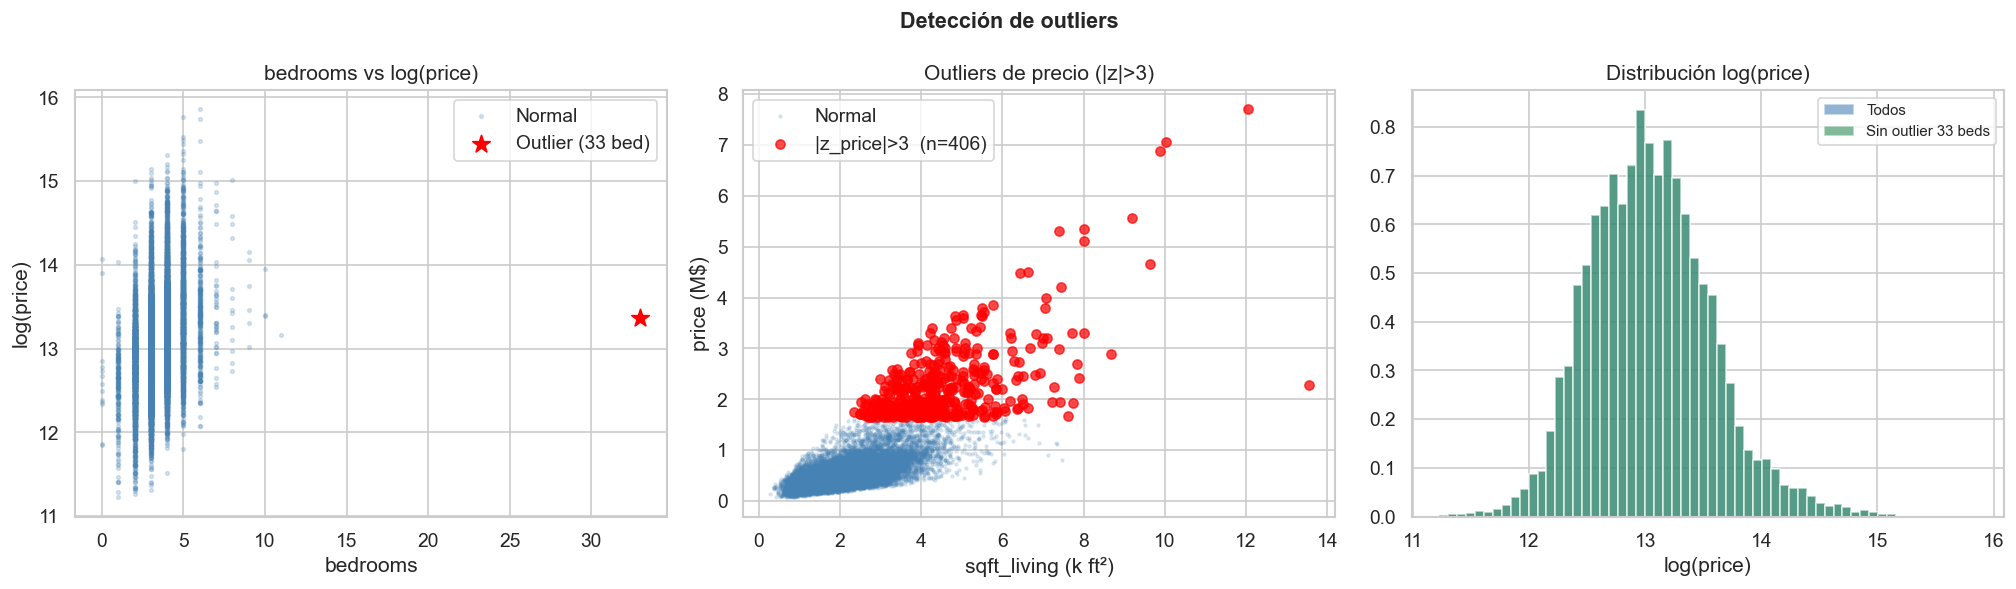

Outliers de precio (|z|>3): 406 viviendas (1.88%)
Rango de precio: $1.6M – $7.7M
→ Son mansiones reales: se mantienen. La log-transformación mitiga su influencia.


In [24]:
df['z_price']      = np.abs(stats.zscore(df['price']))
df['z_sqft_living'] = np.abs(stats.zscore(df['sqft_living']))
outliers_price     = df[df['z_price'] > 3]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Detección de outliers', fontsize=13, fontweight='bold')

# bedrooms vs log_price
mask_normal = df['bedrooms'] != 33
axes[0].scatter(df.loc[mask_normal, 'bedrooms'], df.loc[mask_normal, 'log_price'],
                s=5, alpha=0.2, color='steelblue', label='Normal')
axes[0].scatter(df.loc[~mask_normal, 'bedrooms'], df.loc[~mask_normal, 'log_price'],
                s=120, color='red', marker='*', zorder=5, label='Outlier (33 bed)')
axes[0].set_xlabel('bedrooms'); axes[0].set_ylabel('log(price)')
axes[0].set_title('bedrooms vs log(price)')
axes[0].legend()

# sqft_living vs price con outliers marcados
axes[1].scatter(df['sqft_living']/1e3, df['price']/1e6,
                s=3, alpha=0.15, color='steelblue', label='Normal')
axes[1].scatter(outliers_price['sqft_living']/1e3, outliers_price['price']/1e6,
                s=30, color='red', alpha=0.7,
                label=f'|z_price|>3  (n={len(outliers_price)})')
axes[1].set_xlabel('sqft_living (k ft²)'); axes[1].set_ylabel('price (M$)')
axes[1].set_title('Outliers de precio (|z|>3)')
axes[1].legend()

# Distribución log_price sin vs con outliers
axes[2].hist(df['log_price'], bins=60, alpha=0.6, color='steelblue',
             density=True, label='Todos', edgecolor='white')
df_clean = df[df['bedrooms'] != 33]
axes[2].hist(df_clean['log_price'], bins=60, alpha=0.6, color='seagreen',
             density=True, label='Sin outlier 33 beds', edgecolor='white')
axes[2].set_xlabel('log(price)'); axes[2].set_title('Distribución log(price)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_PATH + '16_outliers.png', bbox_inches='tight')
plt.show()

print(f'Outliers de precio (|z|>3): {len(outliers_price)} viviendas ({len(outliers_price)/len(df)*100:.2f}%)')
print(f'Rango de precio: ${outliers_price["price"].min()/1e6:.1f}M – ${outliers_price["price"].max()/1e6:.1f}M')
print('→ Son mansiones reales: se mantienen. La log-transformación mitiga su influencia.')

df.drop(columns=['z_price', 'z_sqft_living'], inplace=True)

---
## 15. Resumen y decisiones para preprocessing

Todo lo aprendido en el EDA se traduce en decisiones concretas que se implementarán en el **notebook 02 (preprocessing)**.

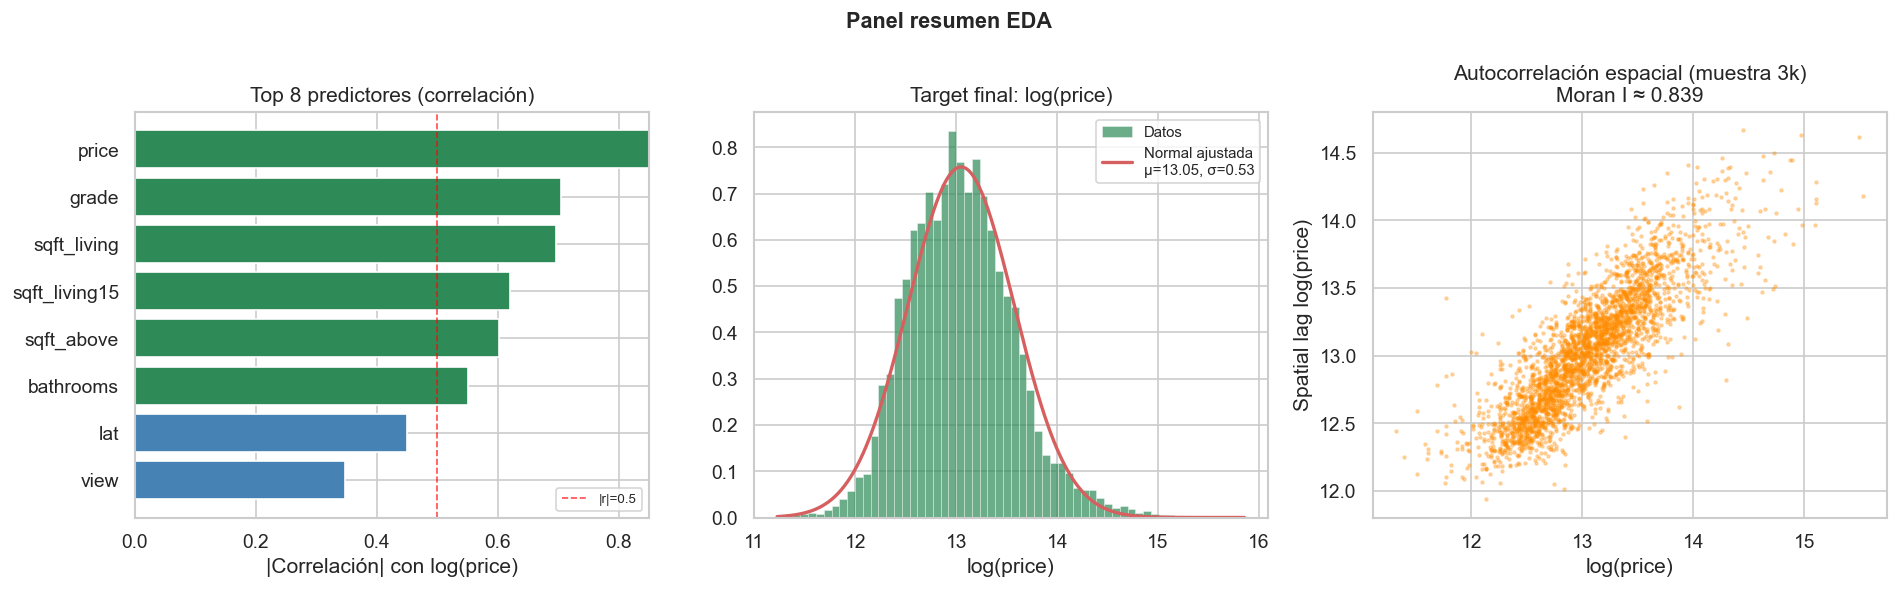

In [25]:
# Panel visual de resumen
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Panel resumen EDA', fontsize=13, fontweight='bold')

# Top 8 correlaciones absolutas con log_price
top_corr = (df[num_cols].corr()['log_price']
            .drop('log_price').abs()
            .sort_values(ascending=True)
            .tail(8))
bar_colors = ['seagreen' if v > 0.5 else 'steelblue' for v in top_corr.values]
axes[0].barh(top_corr.index, top_corr.values, color=bar_colors, edgecolor='white')
axes[0].axvline(0.5, color='red', linestyle='--', lw=1, alpha=0.7, label='|r|=0.5')
axes[0].set_xlabel('|Correlación| con log(price)')
axes[0].set_title('Top 8 predictores (correlación)')
axes[0].set_xlim(0, 0.85)
axes[0].legend(fontsize=8)

# Distribución final log(price) con curva normal ajustada
mu, sigma = df['log_price'].mean(), df['log_price'].std()
x_n = np.linspace(df['log_price'].min(), df['log_price'].max(), 300)
axes[1].hist(df['log_price'], bins=60, color='seagreen', edgecolor='white',
             linewidth=0.3, density=True, alpha=0.7, label='Datos')
axes[1].plot(x_n, norm.pdf(x_n, mu, sigma), 'r-', lw=2,
             label=f'Normal ajustada\nμ={mu:.2f}, σ={sigma:.2f}')
axes[1].set_xlabel('log(price)'); axes[1].set_title('Target final: log(price)')
axes[1].legend(fontsize=9)

# Diagrama de Moran resumido
sample_idx = np.random.RandomState(SEED).choice(len(df), 3000, replace=False)
axes[2].scatter(
    df['log_price'].values[sample_idx],
    df['spatial_lag_log_price'].values[sample_idx],
    s=3, alpha=0.3, color='darkorange'
)
axes[2].set_xlabel('log(price)'); axes[2].set_ylabel('Spatial lag log(price)')
axes[2].set_title(f'Autocorrelación espacial (muestra 3k)\nMoran I ≈ {r_moran:.3f}')

plt.tight_layout()
plt.savefig(FIG_PATH + '17_panel_resumen.png', bbox_inches='tight')
plt.show()

In [26]:
# Resumen textual de decisiones
t_stat_renov, p_renov = stats.ttest_ind(
    df[df['renovated']==0]['log_price'],
    df[df['renovated']==1]['log_price']
)

print('=' * 68)
print('  RESUMEN EDA — DECISIONES PARA PREPROCESSING (notebook 02)')
print('=' * 68)
print(f"""
DATASET GENERAL
  Observaciones : {len(df):,}
  Variables raw : {df.shape[1]}
  Nulos         : 0  ✓
  Periodo       : {df['date_parsed'].min().date()} – {df['date_parsed'].max().date()}

VARIABLE OBJETIVO
  price rango   : ${df['price'].min():,.0f} – ${df['price'].max():,.0f}
  Skewness orig : {df['price'].skew():.3f}  →  log(price): {df['log_price'].skew():.3f}
  DECISIÓN      : usar log(price) como target  ✓

OUTLIERS
  bedrooms=33   : 1 vivienda (error de entrada) → ELIMINAR  ✓
  Outliers precio |z|>3 : {int((np.abs(stats.zscore(df['price']))>3).sum())} viviendas → MANTENER (mansiones reales)  ✓

TRANSFORMACIONES NECESARIAS
  yr_renovated  : 0 = sin renovar → binarizar a renovated (0/1)  ✓
                  t-test renovadas vs no: p={p_renov:.2e}  (diferencia sig.)  ✓
  date          : extraer sale_month (estacionalidad)  ✓
  id            : descartar (no predictivo)  ✓
  sqft_basement : valorar descartar (= sqft_living − sqft_above)  ?

CORRELACIONES TOP con log(price)
  sqft_living   : r = {df['sqft_living'].corr(df['log_price']):.3f}  (predictor más fuerte)
  grade         : r = {df['grade'].corr(df['log_price']):.3f}
  sqft_above    : r = {df['sqft_above'].corr(df['log_price']):.3f}
  sqft_living15 : r = {df['sqft_living15'].corr(df['log_price']):.3f}  (spatial lag nativo)
  bathrooms     : r = {df['bathrooms'].corr(df['log_price']):.3f}

DIMENSIÓN ESPACIAL
  Moran I (K=10): {r_moran:.4f}  → autocorrelación espacial muy alta
  ZIP η²        : {eta2:.3f} ({eta2*100:.1f}% varianza explicada solo por ZIP)
  DECISIÓN      : construir KNN lags con lat/long en notebook 03  ✓
""")
print('=' * 68)

figs_generadas = [f for f in os.listdir(FIG_PATH) if f.endswith('.png')]
print(f'\nFiguras guardadas en {FIG_PATH}: {len(figs_generadas)} archivos')
for f in sorted(figs_generadas):
    print(f'  {f}')

  RESUMEN EDA — DECISIONES PARA PREPROCESSING (notebook 02)

DATASET GENERAL
  Observaciones : 21,613
  Variables raw : 27
  Nulos         : 0  ✓
  Periodo       : 2014-05-02 – 2015-05-27

VARIABLE OBJETIVO
  price rango   : $75,000 – $7,700,000
  Skewness orig : 4.024  →  log(price): 0.428
  DECISIÓN      : usar log(price) como target  ✓

OUTLIERS
  bedrooms=33   : 1 vivienda (error de entrada) → ELIMINAR  ✓
  Outliers precio |z|>3 : 406 viviendas → MANTENER (mansiones reales)  ✓

TRANSFORMACIONES NECESARIAS
  yr_renovated  : 0 = sin renovar → binarizar a renovated (0/1)  ✓
                  t-test renovadas vs no: p=1.43e-63  (diferencia sig.)  ✓
  date          : extraer sale_month (estacionalidad)  ✓
  id            : descartar (no predictivo)  ✓
  sqft_basement : valorar descartar (= sqft_living − sqft_above)  ?

CORRELACIONES TOP con log(price)
  sqft_living   : r = 0.695  (predictor más fuerte)
  grade         : r = 0.704
  sqft_above    : r = 0.602
  sqft_living15 : r = 0.619  